In [32]:
import numpy as np
from numpy import linalg
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import cvxopt
import cvxopt.solvers
from sklearn import svm
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
# Chia dữ liệu thành tập train và test
from sklearn.model_selection import train_test_split
import pandas as pd
import scipy.io as sio
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

# Ví dụ 1

## Cách 1

In [1]:
#Kernel linear: K(u, v) = u^T.v
def linear_kernel(x1, x2):
    return np.dot(x1, x2)
#Kernel poly: K(u, v) = (r + \gamma u^T.v)^d
def polynomial_kernel(x, y, gamma = 1, r = 1, d=3):
    return (r + gamma*np.dot(x, y)) ** d
#Kernel radial basic function (rbf) or gaussian: K(u, v) = e^[-\gamma|u-v|^2]
def gaussian_kernel(x, y, sigma=5.0):
    # gamma = 1.0/(2 * (sigma ** 2))
    return np.exp(-linalg.norm(x-y)**2 / (2 * (sigma ** 2)))

     pcost       dcost       gap    pres   dres
 0: -6.9864e+00 -1.1372e+01  4e+02  2e+01  2e+00
 1: -4.2760e+00 -1.0151e+00  4e+01  2e+00  2e-01
 2: -4.3352e-02 -3.0070e-01  6e-01  1e-02  1e-03
 3: -8.6392e-02 -1.6181e-01  8e-02  6e-04  6e-05
 4: -1.2204e-01 -1.5263e-01  3e-02  1e-04  1e-05
 5: -1.4103e-01 -1.4631e-01  5e-03  2e-05  2e-06
 6: -1.4491e-01 -1.4524e-01  3e-04  6e-08  5e-09
 7: -1.4521e-01 -1.4521e-01  3e-06  6e-10  5e-11
 8: -1.4521e-01 -1.4521e-01  3e-08  6e-12  5e-13
Optimal solution found.
9 support vectors out of 180 points
20 out of 20 predictions correct


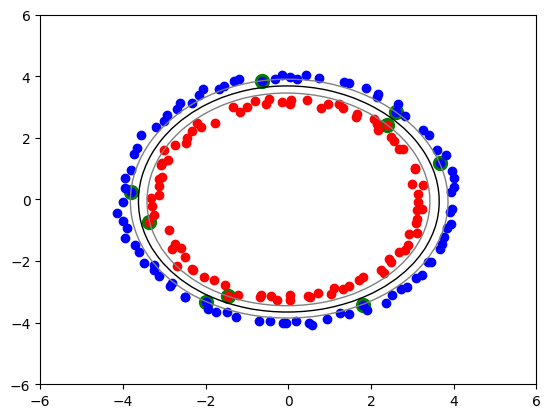

In [9]:
class SVM(object):

    def __init__(self, kernel=linear_kernel, C=None):
        self.kernel = kernel
        self.C = C
        if self.C is not None: self.C = float(self.C)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Gram matrix
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i,j] = self.kernel(X[i], X[j])

        P = cvxopt.matrix(np.outer(y,y) * K)
        q = cvxopt.matrix(np.ones(n_samples) * -1)
        A = cvxopt.matrix(y, (1,n_samples))
        b = cvxopt.matrix(0.0)

        if self.C is None:
            G = cvxopt.matrix(np.diag(np.ones(n_samples) * -1))
            h = cvxopt.matrix(np.zeros(n_samples))
        else:
            tmp1 = np.diag(np.ones(n_samples) * -1)
            tmp2 = np.identity(n_samples)
            G = cvxopt.matrix(np.vstack((tmp1, tmp2)))
            tmp1 = np.zeros(n_samples)
            tmp2 = np.ones(n_samples) * self.C
            h = cvxopt.matrix(np.hstack((tmp1, tmp2)))

        # solve QP problem
        solution = cvxopt.solvers.qp(P, q, G, h, A, b)

        # Lagrange multipliers
        a = np.ravel(solution['x'])

        # Support vectors have non zero lagrange multipliers
        sv = a > 1e-5
        ind = np.arange(len(a))[sv]
        self.a = a[sv]
        self.sv = X[sv]
        self.sv_y = y[sv]
        print("%d support vectors out of %d points" % (len(self.a), n_samples))

        # Intercept
        self.b = 0
        for n in range(len(self.a)):
            self.b += self.sv_y[n]
            self.b -= np.sum(self.a * self.sv_y * K[ind[n],sv])
        self.b /= len(self.a)

        # Weight vector
        if self.kernel == linear_kernel:
            self.w = np.zeros(n_features)
            for n in range(len(self.a)):
                self.w += self.a[n] * self.sv_y[n] * self.sv[n]
        else:
            self.w = None

    def project(self, X):
        if self.w is not None:
            return np.dot(X, self.w) + self.b
        else:
            y_predict = np.zeros(len(X))
            for i in range(len(X)):
                s = 0
                for a, sv_y, sv in zip(self.a, self.sv_y, self.sv):
                    s += a * sv_y * self.kernel(X[i], sv)
                y_predict[i] = s
            return y_predict + self.b

    def predict(self, X):
        return np.sign(self.project(X))

if __name__ == "__main__":
    import pylab as pl

    def gen_lin_separable_data():
        # generate training data in the 2-d case
        mean1 = np.array([0, 2])
        mean2 = np.array([2, 0])
        cov = np.array([[0.8, 0.6], [0.6, 0.8]])
        X1 = np.random.multivariate_normal(mean1, cov, 100)
        y1 = np.ones(len(X1))
        X2 = np.random.multivariate_normal(mean2, cov, 100)
        y2 = np.ones(len(X2)) * -1
        return X1, y1, X2, y2

    def gen_non_lin_separable_data():
        mean1 = [-1, 2]
        mean2 = [1, -1]
        mean3 = [4, -4]
        mean4 = [-4, 4]
        cov = [[1.0,0.8], [0.8, 1.0]]
        X1 = np.random.multivariate_normal(mean1, cov, 50)
        X1 = np.vstack((X1, np.random.multivariate_normal(mean3, cov, 50)))
        y1 = np.ones(len(X1))
        X2 = np.random.multivariate_normal(mean2, cov, 50)
        X2 = np.vstack((X2, np.random.multivariate_normal(mean4, cov, 50)))
        y2 = np.ones(len(X2)) * -1
        return X1, y1, X2, y2

    def gen_circle_data():
        # Generate dataset and targets
        X, Y = make_circles(n_samples = 200, noise = 0.02)
        X1 = 4.0*X[Y==1, :]
        X2 = 4.0*X[Y==0, :]
        y1 = np.ones(len(X1))
        y2 = np.ones(len(X2)) * -1

        return X1, y1, X2, y2     
    
    def gen_lin_separable_overlap_data():
        # generate training data in the 2-d case
        mean1 = np.array([0, 2])
        mean2 = np.array([2, 0])
        cov = np.array([[1.5, 1.0], [1.0, 1.5]])
        X1 = np.random.multivariate_normal(mean1, cov, 100)
        y1 = np.ones(len(X1))
        X2 = np.random.multivariate_normal(mean2, cov, 100)
        y2 = np.ones(len(X2)) * -1
        return X1, y1, X2, y2

    def split_train(X1, y1, X2, y2):
        X1_train = X1[:90]
        y1_train = y1[:90]
        X2_train = X2[:90]
        y2_train = y2[:90]
        X_train = np.vstack((X1_train, X2_train))
        y_train = np.hstack((y1_train, y2_train))
        return X_train, y_train

    def split_test(X1, y1, X2, y2):
        X1_test = X1[90:]
        y1_test = y1[90:]
        X2_test = X2[90:]
        y2_test = y2[90:]
        X_test = np.vstack((X1_test, X2_test))
        y_test = np.hstack((y1_test, y2_test))
        return X_test, y_test

    def plot_margin(X1_train, X2_train, clf):
        def f(x, w, b, c=0):
            # given x, return y such that [x,y] in on the line
            # w.x + b = c
            return (-w[0] * x - b + c) / w[1]

        pl.plot(X1_train[:,0], X1_train[:,1], "ro")
        pl.plot(X2_train[:,0], X2_train[:,1], "bo")
        pl.scatter(clf.sv[:,0], clf.sv[:,1], s=100, c="g")

        # w.x + b = 0
        a0 = -4; a1 = f(a0, clf.w, clf.b)
        b0 = 4; b1 = f(b0, clf.w, clf.b)
        pl.plot([a0,b0], [a1,b1], "k")

        # w.x + b = 1
        a0 = -4; a1 = f(a0, clf.w, clf.b, 1)
        b0 = 4; b1 = f(b0, clf.w, clf.b, 1)
        pl.plot([a0,b0], [a1,b1], "k--")

        # w.x + b = -1
        a0 = -4; a1 = f(a0, clf.w, clf.b, -1)
        b0 = 4; b1 = f(b0, clf.w, clf.b, -1)
        pl.plot([a0,b0], [a1,b1], "k--")

        pl.axis("tight")
        pl.show()

    def plot_contour(X1_train, X2_train, clf):
        pl.plot(X1_train[:,0], X1_train[:,1], "ro")
        pl.plot(X2_train[:,0], X2_train[:,1], "bo")
        pl.scatter(clf.sv[:,0], clf.sv[:,1], s=100, c="g")

        X1, X2 = np.meshgrid(np.linspace(-6,6,50), np.linspace(-6,6,50))
        X = np.array([[x1, x2] for x1, x2 in zip(np.ravel(X1), np.ravel(X2))])
        Z = clf.project(X).reshape(X1.shape)
        pl.contour(X1, X2, Z, [0.0], colors='k', linewidths=1, origin='lower')
        pl.contour(X1, X2, Z + 1, [0.0], colors='grey', linewidths=1, origin='lower')
        pl.contour(X1, X2, Z - 1, [0.0], colors='grey', linewidths=1, origin='lower')

        pl.axis("tight")
        pl.show()

    def test_linear():
        X1, y1, X2, y2 = gen_lin_separable_data()
        X_train, y_train = split_train(X1, y1, X2, y2)
        X_test, y_test = split_test(X1, y1, X2, y2)

        clf = SVM()
        clf.fit(X_train, y_train)

        y_predict = clf.predict(X_test)
        correct = np.sum(y_predict == y_test)
        print("%d out of %d predictions correct" % (correct, len(y_predict)))

        plot_margin(X_train[y_train==1], X_train[y_train==-1], clf)

    def test_non_linear():
        X1, y1, X2, y2 = gen_circle_data()
        #X1, y1, X2, y2 = gen_non_lin_separable_data()
        X_train, y_train = split_train(X1, y1, X2, y2)
        X_test, y_test = split_test(X1, y1, X2, y2)

        clf = SVM(polynomial_kernel)
        #clf = SVM(gaussian_kernel)
        clf.fit(X_train, y_train)

        y_predict = clf.predict(X_test)
        correct = np.sum(y_predict == y_test)
        print("%d out of %d predictions correct" % (correct, len(y_predict)))

        plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)

    def test_soft():
        X1, y1, X2, y2 = gen_lin_separable_overlap_data()
        X_train, y_train = split_train(X1, y1, X2, y2)
        X_test, y_test = split_test(X1, y1, X2, y2)

        clf = SVM(C=1000.1)
        clf.fit(X_train, y_train)

        y_predict = clf.predict(X_test)
        correct = np.sum(y_predict == y_test)
        print("%d out of %d predictions correct" % (correct, len(y_predict)))

        plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)

        
    #test_linear()
    test_non_linear()
    #test_soft()

## Cách 2

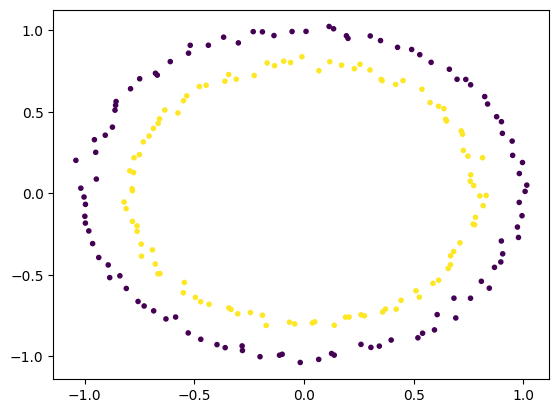

In [11]:
# Generate dataset and targets
X, Y = make_circles(n_samples = 200, noise = 0.02)

# visualizing data
plt.scatter(X[:, 0], X[:, 1], c = Y, marker = '.')
plt.show()

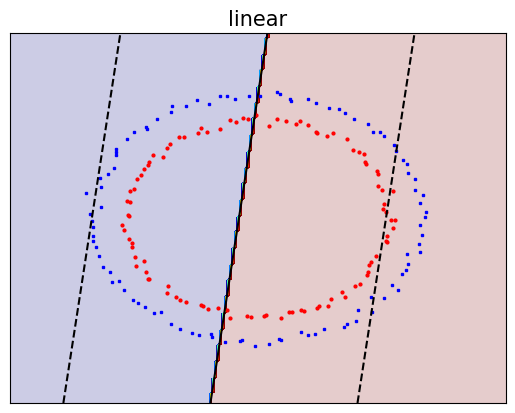

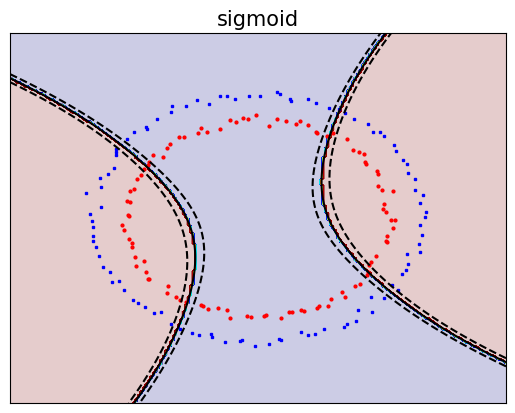

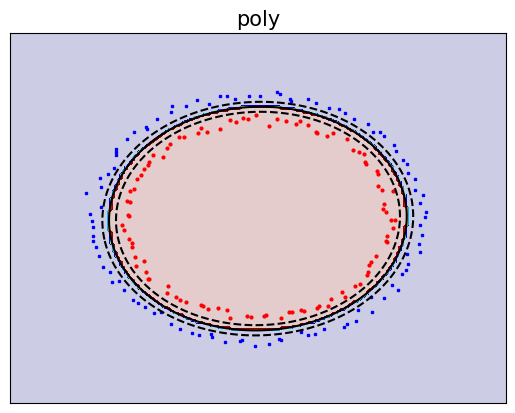

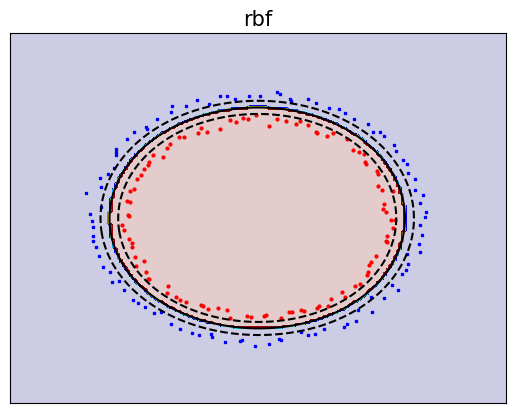

In [14]:
fignum = 1
# fit the model
for kernel in ('linear','sigmoid', 'poly', 'rbf'):
    clf = svm.SVC(kernel=kernel, gamma=1, coef0 = 1)
    clf.fit(X, Y)
    with PdfPages(kernel + '3.pdf') as pdf:
        # plot the line, the points, and the nearest vectors to the plane
        fig, ax = plt.subplots()
        plt.figure(fignum, figsize=(5, 5))
        plt.clf()
        plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80,
        facecolors='None')
        plt.plot(X[Y==0, 0], X[Y==0, 1], 'bs', markersize = 2)
        plt.plot(X[Y==1, 0], X[Y==1, 1], 'ro', markersize = 2)
        plt.axis('tight')
        x_min = -1.5
        x_max = 1.5
        y_min = -1.5
        y_max = 1.5
        XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
        Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
        # Put the result into a color plot
        Z = Z.reshape(XX.shape)
        plt.figure(fignum, figsize=(5, 5))
        CS = plt.contourf(XX, YY, np.sign(Z), 200, cmap='jet', alpha = .2)
        plt.contour(XX, YY, Z, colors=['k', 'k', 'k'], linestyles=['--', '-', '--'],
        levels=[-.5, 0, .5])
        plt.title(kernel, fontsize = 15)
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.xticks(())
        plt.yticks(())
        fignum = fignum + 1
        pdf.savefig()
plt.show()

## Bài tập 1

In [16]:
# Generate dataset
X, Y = make_circles(n_samples=200, noise=0.02)

# Chia dữ liệu: 80% train, 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Số lượng mẫu train: {len(X_train)}")
print(f"Số lượng mẫu test: {len(X_test)}")

Số lượng mẫu train: 160
Số lượng mẫu test: 40



Kernel: LINEAR

Độ chính xác (Accuracy): 0.5000 (50.00%)

Ma trận nhầm lẫn (Confusion Matrix):
[[ 9 11]
 [ 9 11]]


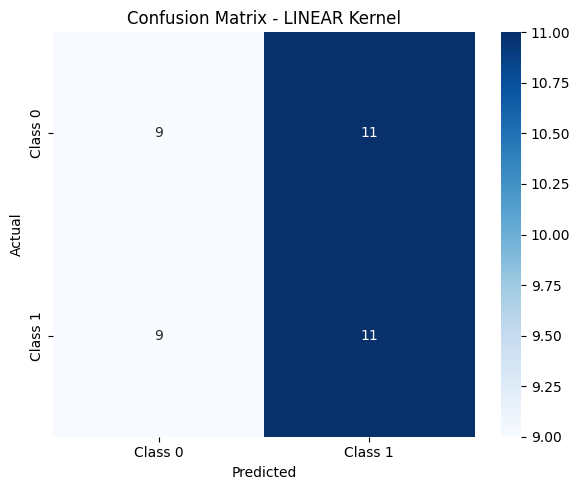


Phân tích chi tiết:
  - True Negatives (TN): 9
  - False Positives (FP): 11
  - False Negatives (FN): 9
  - True Positives (TP): 11

Kernel: SIGMOID

Độ chính xác (Accuracy): 0.6250 (62.50%)

Ma trận nhầm lẫn (Confusion Matrix):
[[10 10]
 [ 5 15]]


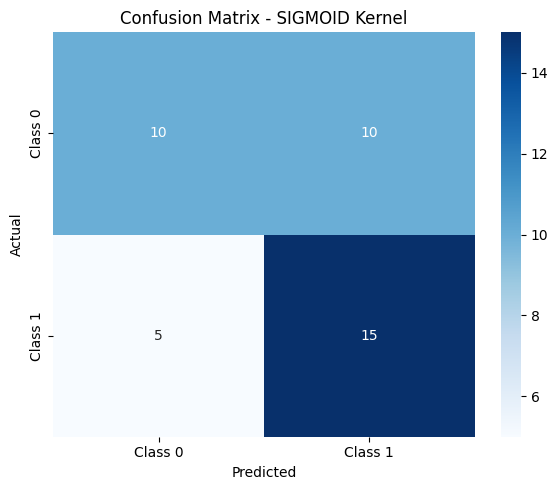


Phân tích chi tiết:
  - True Negatives (TN): 10
  - False Positives (FP): 10
  - False Negatives (FN): 5
  - True Positives (TP): 15

Kernel: POLY

Độ chính xác (Accuracy): 1.0000 (100.00%)

Ma trận nhầm lẫn (Confusion Matrix):
[[20  0]
 [ 0 20]]


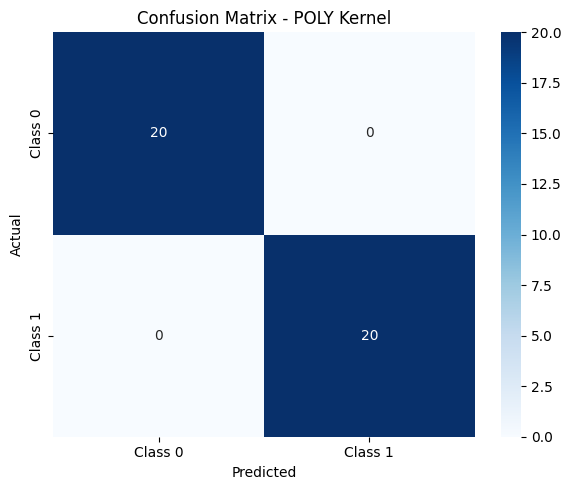


Phân tích chi tiết:
  - True Negatives (TN): 20
  - False Positives (FP): 0
  - False Negatives (FN): 0
  - True Positives (TP): 20

Kernel: RBF

Độ chính xác (Accuracy): 1.0000 (100.00%)

Ma trận nhầm lẫn (Confusion Matrix):
[[20  0]
 [ 0 20]]


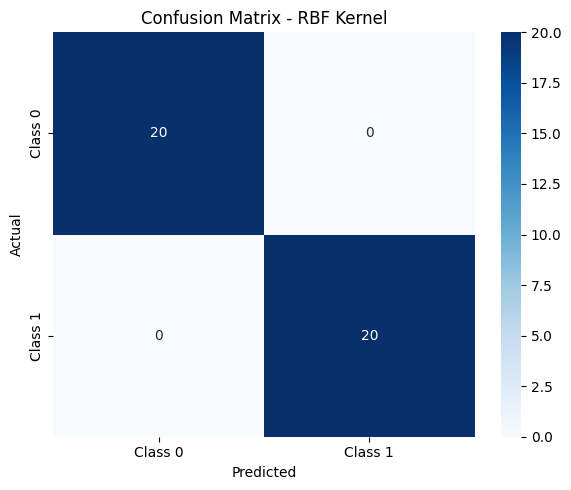


Phân tích chi tiết:
  - True Negatives (TN): 20
  - False Positives (FP): 0
  - False Negatives (FN): 0
  - True Positives (TP): 20


In [17]:
# Danh sách các kernel để test
kernels = ['linear', 'sigmoid', 'poly', 'rbf']

# Dictionary để lưu kết quả
results = {}

# Training và đánh giá cho mỗi kernel
for kernel_name in kernels:
    print(f"\n{'='*60}")
    print(f"Kernel: {kernel_name.upper()}")
    print(f"{'='*60}")
    
    # Khởi tạo và train model
    clf = svm.SVC(kernel=kernel_name, gamma=1, coef0=1)
    clf.fit(X_train, Y_train)
    
    # Dự đoán trên tập test
    Y_pred = clf.predict(X_test)
    
    # Tính accuracy
    accuracy = accuracy_score(Y_test, Y_pred)
    
    # Tính confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    
    # Lưu kết quả
    results[kernel_name] = {
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'model': clf
    }
    
    # In kết quả
    print(f"\nĐộ chính xác (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\nMa trận nhầm lẫn (Confusion Matrix):")
    print(cm)
    
    # Visualize confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    plt.title(f'Confusion Matrix - {kernel_name.upper()} Kernel')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    print(f"\nPhân tích chi tiết:")
    print(f"  - True Negatives (TN): {cm[0,0]}")
    print(f"  - False Positives (FP): {cm[0,1]}")
    print(f"  - False Negatives (FN): {cm[1,0]}")
    print(f"  - True Positives (TP): {cm[1,1]}")


TỔNG HỢP KẾT QUẢ SO SÁNH CÁC KERNEL

  Kernel Accuracy Accuracy (%)
 LINEAR   0.5000       50.00%
SIGMOID   0.6250       62.50%
   POLY   1.0000      100.00%
    RBF   1.0000      100.00%

KERNEL TỐT NHẤT: POLY
Độ chính xác: 1.0000 (100.00%)


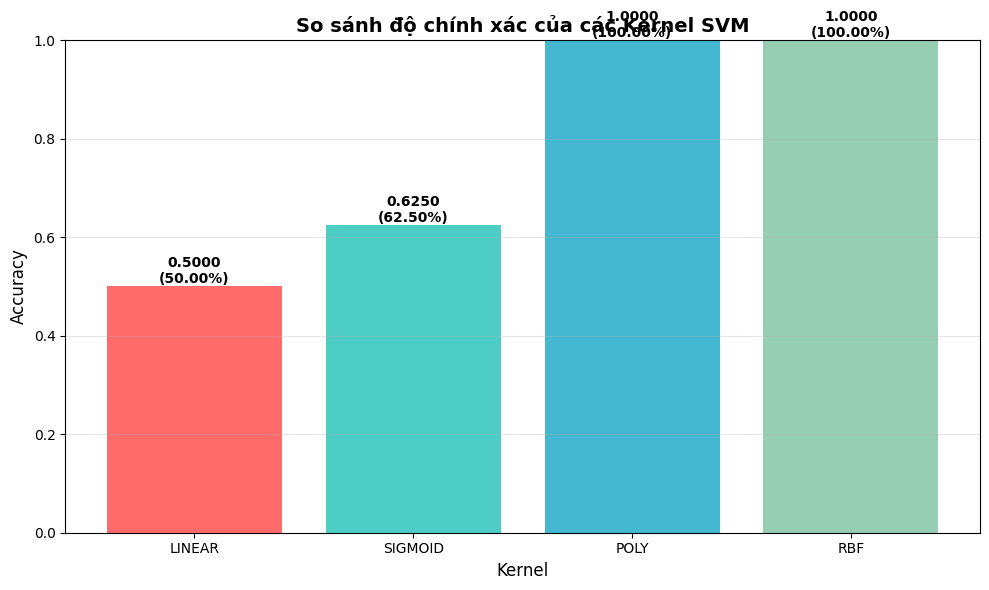

In [18]:
# Tổng hợp kết quả so sánh các kernel
print("\n" + "="*80)
print("TỔNG HỢP KẾT QUẢ SO SÁNH CÁC KERNEL")
print("="*80)

# Tạo DataFrame để hiển thị kết quả
import pandas as pd

comparison_data = []
for kernel_name, result in results.items():
    comparison_data.append({
        'Kernel': kernel_name.upper(),
        'Accuracy': f"{result['accuracy']:.4f}",
        'Accuracy (%)': f"{result['accuracy']*100:.2f}%"
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n", df_comparison.to_string(index=False))

# Tìm kernel tốt nhất
best_kernel = max(results.items(), key=lambda x: x[1]['accuracy'])
print(f"\n{'='*80}")
print(f"KERNEL TỐT NHẤT: {best_kernel[0].upper()}")
print(f"Độ chính xác: {best_kernel[1]['accuracy']:.4f} ({best_kernel[1]['accuracy']*100:.2f}%)")
print(f"{'='*80}")

# Vẽ biểu đồ so sánh accuracy
plt.figure(figsize=(10, 6))
kernel_names = [k.upper() for k in results.keys()]
accuracies = [results[k]['accuracy'] for k in results.keys()]

bars = plt.bar(kernel_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Kernel', fontsize=12)
plt.title('So sánh độ chính xác của các Kernel SVM', fontsize=14, fontweight='bold')
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)

# Thêm giá trị lên trên mỗi cột
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}\n({acc*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Ví dụ 2

In [25]:
# Đọc file dữ liệu
data = pd.read_csv('ex2data2.txt', header=None)
data.columns = ['Test1', 'Test2', 'Accepted']

# Trích xuất features và labels
X = data[['Test1', 'Test2']]
Y = data['Accepted']

print(f"Kích thước dữ liệu: {X.shape}")
print(f"Số lượng mẫu passed (Y=1): {sum(Y==1)}")
print(f"Số lượng mẫu failed (Y=0): {sum(Y==0)}")
print(f"\n5 dòng dữ liệu đầu tiên:")
print(data.head())

Kích thước dữ liệu: (118, 2)
Số lượng mẫu passed (Y=1): 58
Số lượng mẫu failed (Y=0): 60

5 dòng dữ liệu đầu tiên:
      Test1    Test2  Accepted
0  0.051267  0.69956         1
1 -0.092742  0.68494         1
2 -0.213710  0.69225         1
3 -0.375000  0.50219         1
4 -0.513250  0.46564         1


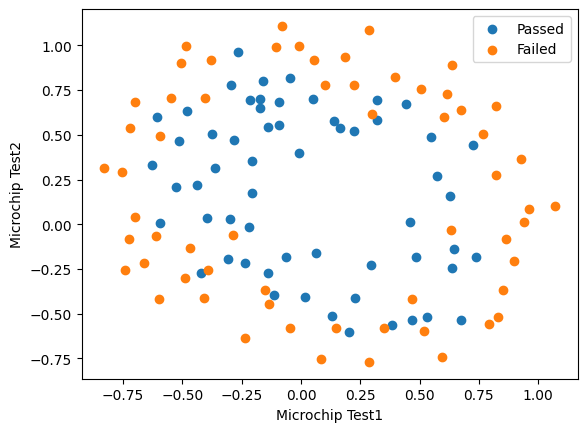

In [30]:
# visualizing data
mask = Y == 1
passed = plt.scatter(X[mask]['Test1'].values, X[mask]['Test2'].values)
failed = plt.scatter(X[~mask]['Test1'].values, X[~mask]['Test2'].values)
plt.xlabel('Microchip Test1')
plt.ylabel('Microchip Test2')
plt.legend((passed, failed), ('Passed', 'Failed'))
plt.show()

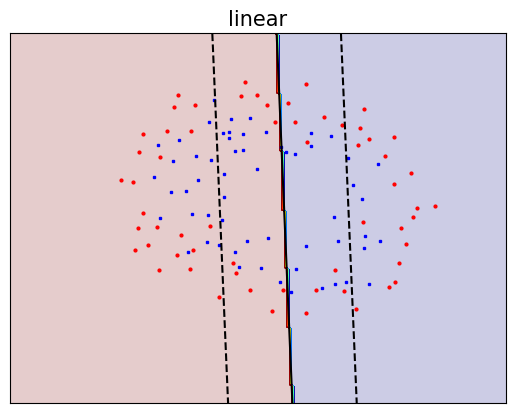

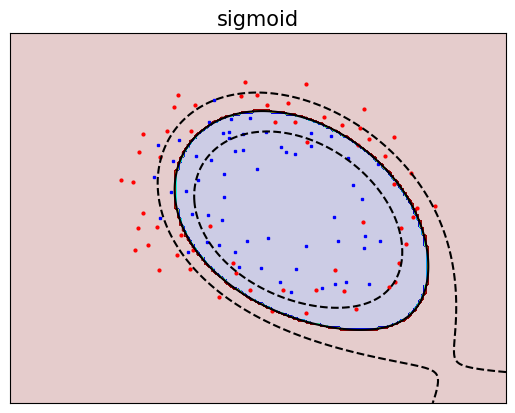

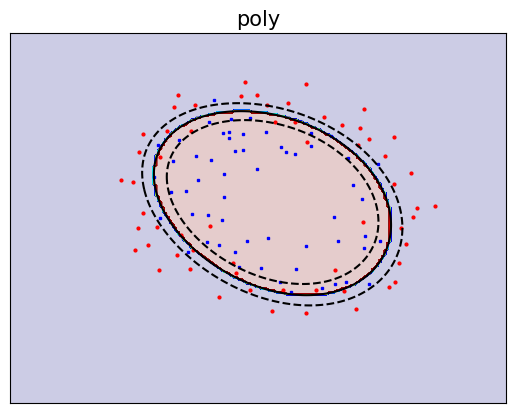

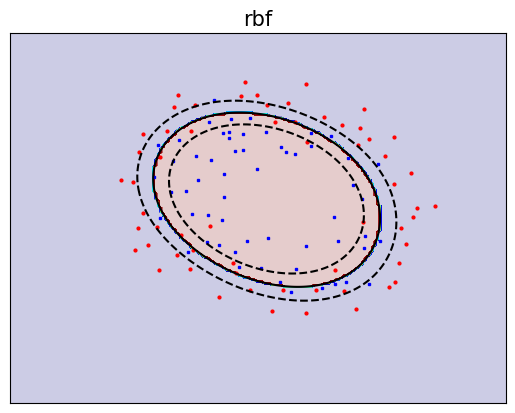

In [ ]:
fignum = 1
# fit the model
for kernel in ('linear','sigmoid', 'poly', 'rbf'):
    clf = svm.SVC(kernel=kernel, gamma=1, coef0 = 1)
    clf.fit(X, Y)
    with PdfPages(kernel + '3.pdf') as pdf:
        # plot the line, the points, and the nearest vectors to the plane
        fig, ax = plt.subplots()
        plt.figure(fignum, figsize=(5, 5))
        plt.clf()
        plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80,
        facecolors='None')
        plt.plot(X[mask]['Test1'].values, X[mask]['Test2'].values, 'bs', markersize = 2)
        plt.plot(X[~mask]['Test1'].values, X[~mask]['Test2'].values, 'ro', markersize = 2)
        plt.axis('tight')
        x_min = -1.5
        x_max = 1.5
        y_min = -1.5
        y_max = 1.5
        XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
        Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
        # Put the result into a color plot
        Z = Z.reshape(XX.shape)
        plt.figure(fignum, figsize=(5, 5))
        CS = plt.contourf(XX, YY, np.sign(Z), 200, cmap='jet', alpha = .2)
        plt.contour(XX, YY, Z, colors=['k', 'k', 'k'], linestyles=['--', '-', '--'],
        levels=[-.5, 0, .5])
        plt.title(kernel, fontsize = 15)
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.xticks(())
        plt.yticks(())
        fignum = fignum + 1
plt.show()

## Bài tập thực hành 1

In [33]:
# Đọc dữ liệu từ file ARgender.mat
A = sio.loadmat(r'D:\\Workspace\\HUS\\Machine Learning\\12. Kernel_SVM\\ARgender.mat')

# Chuẩn bị dữ liệu training và test
X_train = A['Y_train'].T
X_test = A['Y_test'].T
N = 700
y_train = A['label_train'].reshape(N)
y_test = A['label_test'].reshape(N)

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước y_train: {y_train.shape}")
print(f"Kích thước y_test: {y_test.shape}")
print(f"\nSố lượng class trong y_train: {np.unique(y_train)}")
print(f"Số lượng mẫu mỗi class trong y_train: {np.bincount(y_train.astype(int))}")

Kích thước X_train: (700, 300)
Kích thước X_test: (700, 300)
Kích thước y_train: (700,)
Kích thước y_test: (700,)

Số lượng class trong y_train: [1 2]
Số lượng mẫu mỗi class trong y_train: [  0 350 350]


TRAINING VÀ ĐÁNH GIÁ KERNEL SVM CHO DỮ LIỆU ARGENDER

Kernel: LINEAR
Đang training model...
Training hoàn tất! Số support vectors: 306

KẾT QUẢ:
  Accuracy trên tập Training: 0.9129 (91.29%)
  Accuracy trên tập Test: 0.9029 (90.29%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[344   6]
 [ 62 288]]


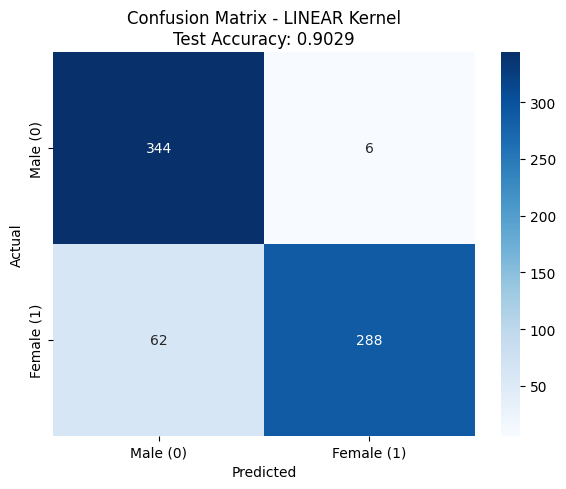


Phân tích chi tiết:
  - True Negatives (TN): 344 (Dự đoán đúng Male)
  - False Positives (FP): 6 (Dự đoán sai thành Female)
  - False Negatives (FN): 62 (Dự đoán sai thành Male)
  - True Positives (TP): 288 (Dự đoán đúng Female)

Kernel: SIGMOID
Đang training model...
Training hoàn tất! Số support vectors: 613

KẾT QUẢ:
  Accuracy trên tập Training: 0.8743 (87.43%)
  Accuracy trên tập Test: 0.8943 (89.43%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[342   8]
 [ 66 284]]


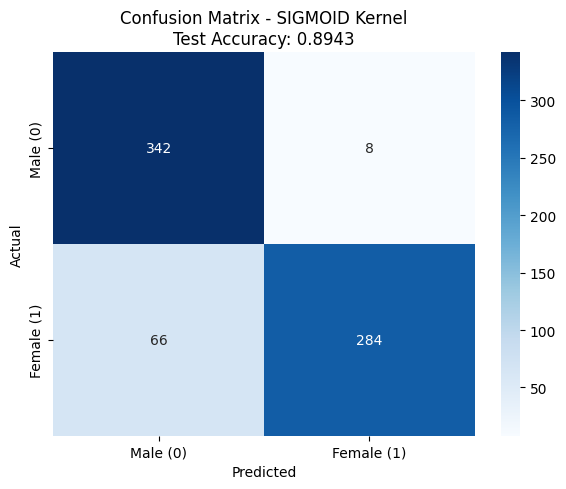


Phân tích chi tiết:
  - True Negatives (TN): 342 (Dự đoán đúng Male)
  - False Positives (FP): 8 (Dự đoán sai thành Female)
  - False Negatives (FN): 66 (Dự đoán sai thành Male)
  - True Positives (TP): 284 (Dự đoán đúng Female)

Kernel: POLY
Đang training model...
Training hoàn tất! Số support vectors: 162

KẾT QUẢ:
  Accuracy trên tập Training: 0.9957 (99.57%)
  Accuracy trên tập Test: 0.9229 (92.29%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[330  20]
 [ 34 316]]


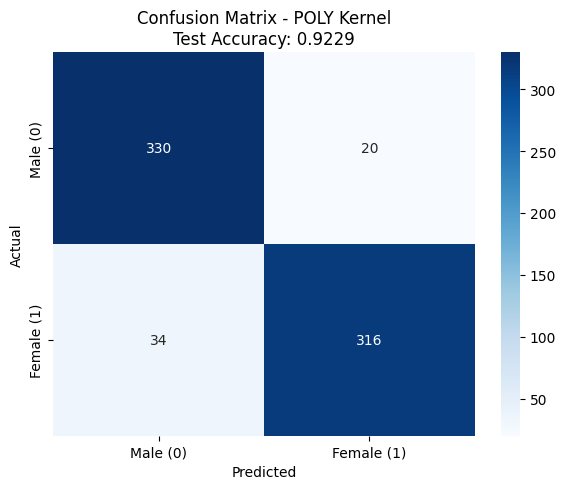


Phân tích chi tiết:
  - True Negatives (TN): 330 (Dự đoán đúng Male)
  - False Positives (FP): 20 (Dự đoán sai thành Female)
  - False Negatives (FN): 34 (Dự đoán sai thành Male)
  - True Positives (TP): 316 (Dự đoán đúng Female)

Kernel: RBF
Đang training model...
Training hoàn tất! Số support vectors: 272

KẾT QUẢ:
  Accuracy trên tập Training: 0.9486 (94.86%)
  Accuracy trên tập Test: 0.9086 (90.86%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[341   9]
 [ 55 295]]


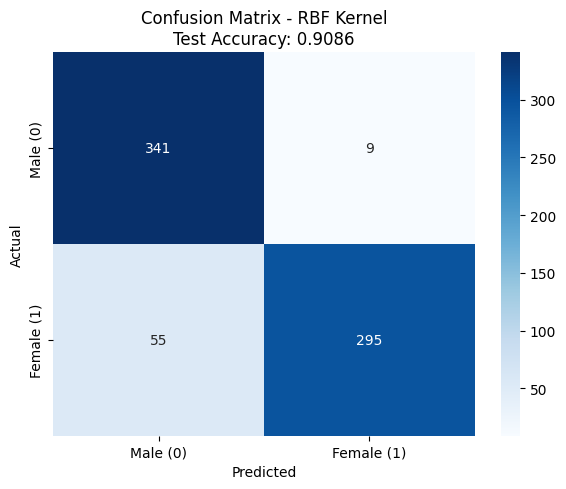


Phân tích chi tiết:
  - True Negatives (TN): 341 (Dự đoán đúng Male)
  - False Positives (FP): 9 (Dự đoán sai thành Female)
  - False Negatives (FN): 55 (Dự đoán sai thành Male)
  - True Positives (TP): 295 (Dự đoán đúng Female)

HOÀN THÀNH TRAINING VÀ ĐÁNH GIÁ TẤT CẢ CÁC KERNEL


In [34]:
# Danh sách các kernel để test
kernels = ['linear', 'sigmoid', 'poly', 'rbf']

# Dictionary để lưu kết quả
results_gender = {}

print("="*80)
print("TRAINING VÀ ĐÁNH GIÁ KERNEL SVM CHO DỮ LIỆU ARGENDER")
print("="*80)

# Training và đánh giá cho mỗi kernel
for kernel_name in kernels:
    print(f"\n{'='*80}")
    print(f"Kernel: {kernel_name.upper()}")
    print(f"{'='*80}")
    
    # Khởi tạo model với kernel tương ứng
    if kernel_name == 'poly':
        clf = SVC(kernel=kernel_name, gamma='scale', coef0=1, degree=3)
    else:
        clf = SVC(kernel=kernel_name, gamma='scale', coef0=1)
    
    # Training
    print("Đang training model...")
    clf.fit(X_train, y_train)
    print(f"Training hoàn tất! Số support vectors: {len(clf.support_vectors_)}")
    
    # Dự đoán trên tập training
    y_train_pred = clf.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    
    # Dự đoán trên tập test
    y_test_pred = clf.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Tính confusion matrix cho tập test
    cm = confusion_matrix(y_test, y_test_pred)
    
    # Lưu kết quả
    results_gender[kernel_name] = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'confusion_matrix': cm,
        'model': clf
    }
    
    # In kết quả
    print(f"\nKẾT QUẢ:")
    print(f"  Accuracy trên tập Training: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"  Accuracy trên tập Test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"\nMa trận nhầm lẫn (Confusion Matrix) trên tập Test:")
    print(cm)
    
    # Visualize confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Male (0)', 'Female (1)'],
                yticklabels=['Male (0)', 'Female (1)'])
    plt.title(f'Confusion Matrix - {kernel_name.upper()} Kernel\nTest Accuracy: {test_accuracy:.4f}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    print(f"\nPhân tích chi tiết:")
    print(f"  - True Negatives (TN): {cm[0,0]} (Dự đoán đúng Male)")
    print(f"  - False Positives (FP): {cm[0,1]} (Dự đoán sai thành Female)")
    print(f"  - False Negatives (FN): {cm[1,0]} (Dự đoán sai thành Male)")
    print(f"  - True Positives (TP): {cm[1,1]} (Dự đoán đúng Female)")

print(f"\n{'='*80}")
print("HOÀN THÀNH TRAINING VÀ ĐÁNH GIÁ TẤT CẢ CÁC KERNEL")
print(f"{'='*80}")


TỔNG HỢP KẾT QUẢ SO SÁNH CÁC KERNEL - ARGENDER DATASET

  Kernel Train Accuracy Train Acc (%) Test Accuracy Test Acc (%)
 LINEAR         0.9129        91.29%        0.9029       90.29%
SIGMOID         0.8743        87.43%        0.8943       89.43%
   POLY         0.9957        99.57%        0.9229       92.29%
    RBF         0.9486        94.86%        0.9086       90.86%

KERNEL TỐT NHẤT (dựa trên Test Accuracy): POLY
Train Accuracy: 0.9957 (99.57%)
Test Accuracy: 0.9229 (92.29%)


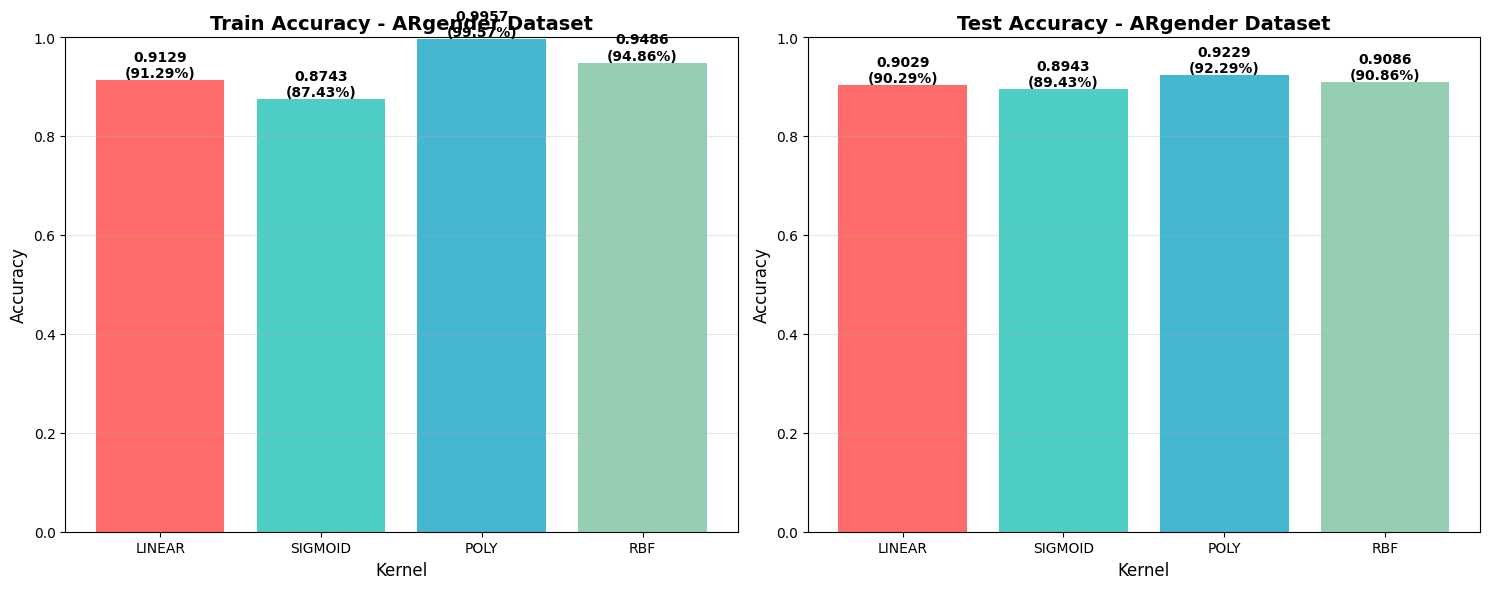

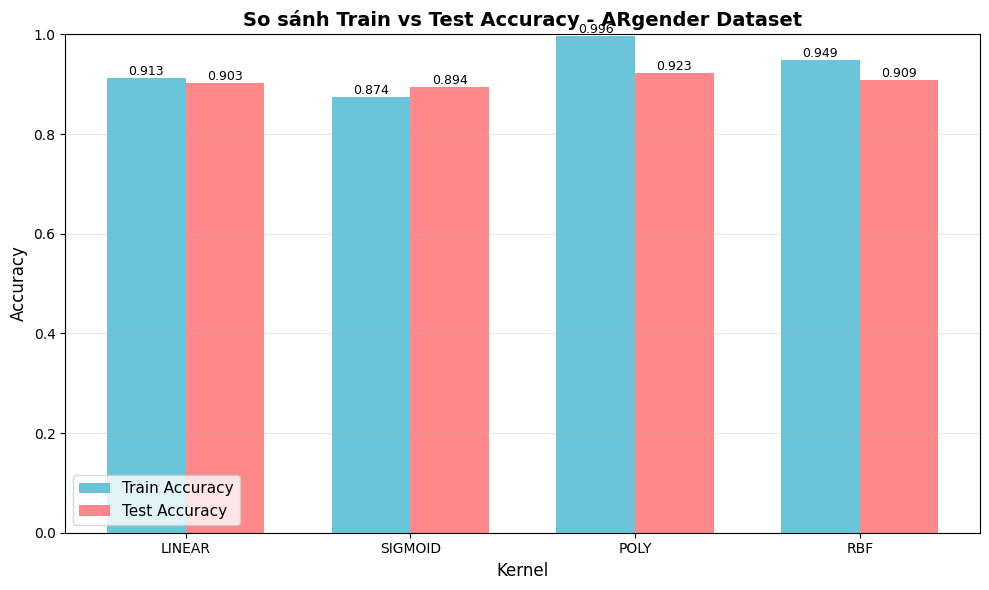

In [35]:
# Tổng hợp và so sánh kết quả các kernel
print("\n" + "="*80)
print("TỔNG HỢP KẾT QUẢ SO SÁNH CÁC KERNEL - ARGENDER DATASET")
print("="*80)

# Tạo DataFrame để hiển thị kết quả
comparison_data_gender = []
for kernel_name, result in results_gender.items():
    comparison_data_gender.append({
        'Kernel': kernel_name.upper(),
        'Train Accuracy': f"{result['train_accuracy']:.4f}",
        'Train Acc (%)': f"{result['train_accuracy']*100:.2f}%",
        'Test Accuracy': f"{result['test_accuracy']:.4f}",
        'Test Acc (%)': f"{result['test_accuracy']*100:.2f}%"
    })

df_comparison_gender = pd.DataFrame(comparison_data_gender)
print("\n", df_comparison_gender.to_string(index=False))

# Tìm kernel tốt nhất dựa trên test accuracy
best_kernel_gender = max(results_gender.items(), key=lambda x: x[1]['test_accuracy'])
print(f"\n{'='*80}")
print(f"KERNEL TỐT NHẤT (dựa trên Test Accuracy): {best_kernel_gender[0].upper()}")
print(f"Train Accuracy: {best_kernel_gender[1]['train_accuracy']:.4f} ({best_kernel_gender[1]['train_accuracy']*100:.2f}%)")
print(f"Test Accuracy: {best_kernel_gender[1]['test_accuracy']:.4f} ({best_kernel_gender[1]['test_accuracy']*100:.2f}%)")
print(f"{'='*80}")

# Vẽ biểu đồ so sánh accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

kernel_names = [k.upper() for k in results_gender.keys()]
train_accuracies = [results_gender[k]['train_accuracy'] for k in results_gender.keys()]
test_accuracies = [results_gender[k]['test_accuracy'] for k in results_gender.keys()]

# Biểu đồ Train Accuracy
bars1 = ax1.bar(kernel_names, train_accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('Kernel', fontsize=12)
ax1.set_title('Train Accuracy - ARgender Dataset', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3)

# Thêm giá trị lên trên mỗi cột
for bar, acc in zip(bars1, train_accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}\n({acc*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Biểu đồ Test Accuracy
bars2 = ax2.bar(kernel_names, test_accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xlabel('Kernel', fontsize=12)
ax2.set_title('Test Accuracy - ARgender Dataset', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1.0])
ax2.grid(axis='y', alpha=0.3)

# Thêm giá trị lên trên mỗi cột
for bar, acc in zip(bars2, test_accuracies):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}\n({acc*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Vẽ biểu đồ so sánh Train vs Test Accuracy
plt.figure(figsize=(10, 6))
x = np.arange(len(kernel_names))
width = 0.35

bars1 = plt.bar(x - width/2, train_accuracies, width, label='Train Accuracy', 
                color='#45B7D1', alpha=0.8)
bars2 = plt.bar(x + width/2, test_accuracies, width, label='Test Accuracy', 
                color='#FF6B6B', alpha=0.8)

plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Kernel', fontsize=12)
plt.title('So sánh Train vs Test Accuracy - ARgender Dataset', fontsize=14, fontweight='bold')
plt.xticks(x, kernel_names)
plt.ylim([0, 1.0])
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

# Thêm giá trị lên trên mỗi cột
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Bài tập thực hành 2

In [36]:
# Đọc dữ liệu từ file dataset.csv
dataset = pd.read_csv(r'D:\\Workspace\\HUS\\Machine Learning\\12. Kernel_SVM\\dataset.csv')

# Hiển thị thông tin về dữ liệu
print("Thông tin về dataset:")
print(dataset.info())
print(f"\nKích thước dataset: {dataset.shape}")
print(f"\n5 dòng đầu tiên:")
print(dataset.head())
print(f"\nThống kê mô tả:")
print(dataset.describe())
print(f"\nPhân bố nhãn Purchased:")
print(dataset['Purchased'].value_counts())

Thông tin về dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB
None

Kích thước dataset: (400, 3)

5 dòng đầu tiên:
   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0

Thống kê mô tả:
              Age  EstimatedSalary   Purchased
count  400.000000       400.000000  400.000000
mean    37.655000     69742.500000    0.357500
std     10.482877     34096.960282    0.479864
min     18.000000     15000.000000    0.000000
25%     29.750000     43000.000000    0.000000
50%     37.000000     70000.000000    0.000000
75%    

In [37]:
# Trích xuất features và labels
X = dataset.iloc[:, :-1].values  # Age và EstimatedSalary
y = dataset.iloc[:, -1].values   # Purchased

# Chia dữ liệu thành tập train và test
from sklearn.model_selection import train_test_split
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.25, random_state=0)

print(f"Kích thước dữ liệu gốc: {X.shape}")
print(f"Kích thước XTrain: {XTrain.shape}")
print(f"Kích thước XTest: {XTest.shape}")
print(f"Kích thước yTrain: {yTrain.shape}")
print(f"Kích thước yTest: {yTest.shape}")

# Chuẩn hóa dữ liệu (Feature Scaling)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
XTrain = sc.fit_transform(XTrain)
XTest = sc.transform(XTest)  # Chú ý: chỉ transform, không fit lại

print(f"\nDữ liệu đã được chuẩn hóa (StandardScaler)")
print(f"Mean của XTrain sau chuẩn hóa: {XTrain.mean(axis=0)}")
print(f"Std của XTrain sau chuẩn hóa: {XTrain.std(axis=0)}")

Kích thước dữ liệu gốc: (400, 2)
Kích thước XTrain: (300, 2)
Kích thước XTest: (100, 2)
Kích thước yTrain: (300,)
Kích thước yTest: (100,)

Dữ liệu đã được chuẩn hóa (StandardScaler)
Mean của XTrain sau chuẩn hóa: [1.45809291e-16 1.50990331e-16]
Std của XTrain sau chuẩn hóa: [1. 1.]


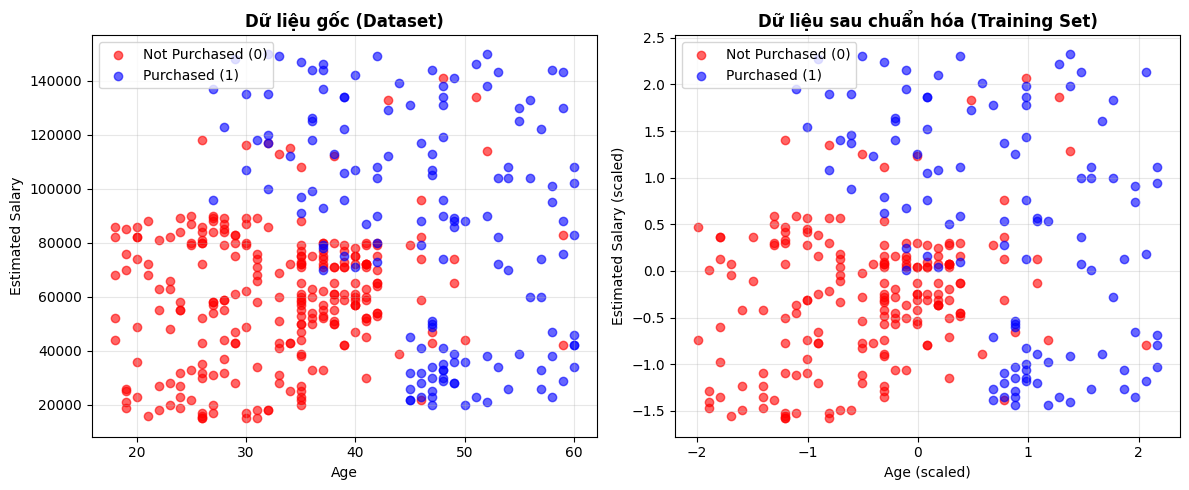

In [38]:
# Visualize dữ liệu trước khi training
plt.figure(figsize=(12, 5))

# Subplot 1: Dữ liệu gốc
plt.subplot(1, 2, 1)
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', label='Not Purchased (0)', alpha=0.6)
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Purchased (1)', alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Dữ liệu gốc (Dataset)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: Dữ liệu sau chuẩn hóa (Training set)
plt.subplot(1, 2, 2)
plt.scatter(XTrain[yTrain==0, 0], XTrain[yTrain==0, 1], c='red', label='Not Purchased (0)', alpha=0.6)
plt.scatter(XTrain[yTrain==1, 0], XTrain[yTrain==1, 1], c='blue', label='Purchased (1)', alpha=0.6)
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('Dữ liệu sau chuẩn hóa (Training Set)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

TRAINING VÀ ĐÁNH GIÁ KERNEL SVM CHO DATASET.CSV

Kernel: LINEAR
Đang training model...
Training hoàn tất! Số support vectors: 128

KẾT QUẢ:
  Accuracy trên tập Training: 0.8233 (82.33%)
  Accuracy trên tập Test: 0.9000 (90.00%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[66  2]
 [ 8 24]]


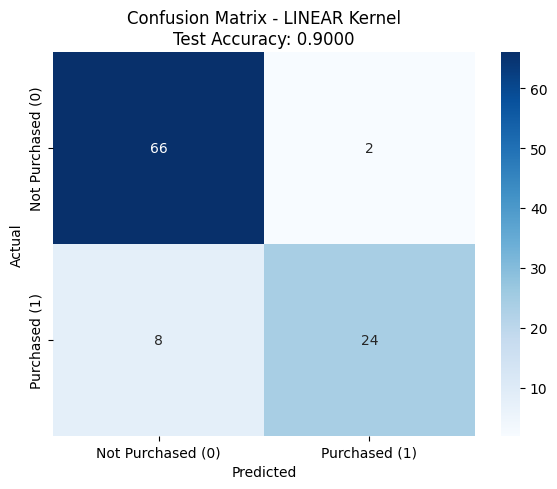


Phân tích chi tiết:
  - True Negatives (TN): 66 (Dự đoán đúng Not Purchased)
  - False Positives (FP): 2 (Dự đoán sai thành Purchased)
  - False Negatives (FN): 8 (Dự đoán sai thành Not Purchased)
  - True Positives (TP): 24 (Dự đoán đúng Purchased)

Kernel: SIGMOID
Đang training model...
Training hoàn tất! Số support vectors: 141

KẾT QUẢ:
  Accuracy trên tập Training: 0.5700 (57.00%)
  Accuracy trên tập Test: 0.7100 (71.00%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[55 13]
 [16 16]]


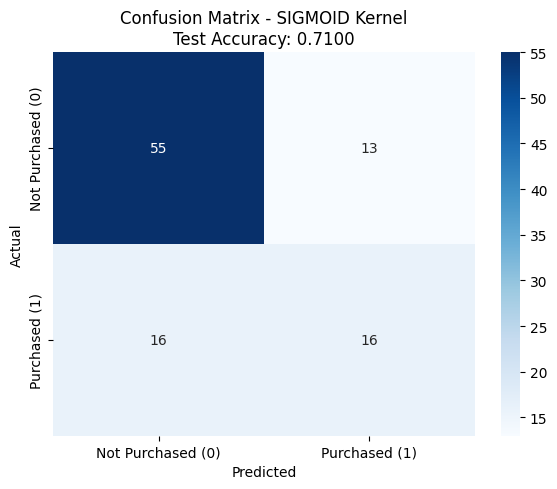


Phân tích chi tiết:
  - True Negatives (TN): 55 (Dự đoán đúng Not Purchased)
  - False Positives (FP): 13 (Dự đoán sai thành Purchased)
  - False Negatives (FN): 16 (Dự đoán sai thành Not Purchased)
  - True Positives (TP): 16 (Dự đoán đúng Purchased)

Kernel: POLY
Đang training model...
Training hoàn tất! Số support vectors: 81

KẾT QUẢ:
  Accuracy trên tập Training: 0.8967 (89.67%)
  Accuracy trên tập Test: 0.9300 (93.00%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[64  4]
 [ 3 29]]


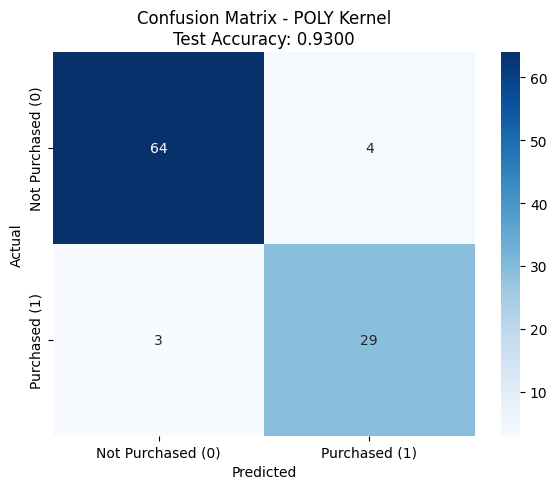


Phân tích chi tiết:
  - True Negatives (TN): 64 (Dự đoán đúng Not Purchased)
  - False Positives (FP): 4 (Dự đoán sai thành Purchased)
  - False Negatives (FN): 3 (Dự đoán sai thành Not Purchased)
  - True Positives (TP): 29 (Dự đoán đúng Purchased)

Kernel: RBF
Đang training model...
Training hoàn tất! Số support vectors: 88

KẾT QUẢ:
  Accuracy trên tập Training: 0.9133 (91.33%)
  Accuracy trên tập Test: 0.9300 (93.00%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[64  4]
 [ 3 29]]


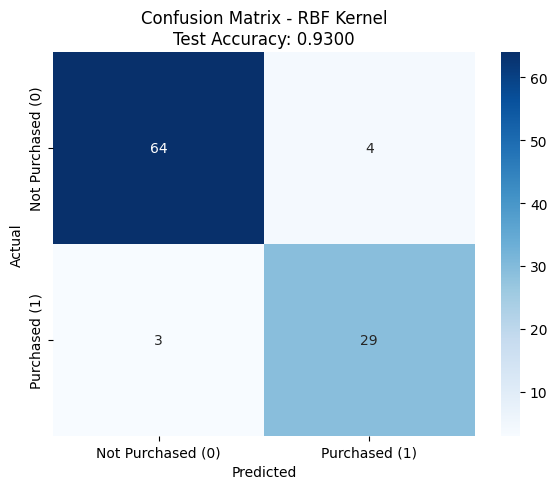


Phân tích chi tiết:
  - True Negatives (TN): 64 (Dự đoán đúng Not Purchased)
  - False Positives (FP): 4 (Dự đoán sai thành Purchased)
  - False Negatives (FN): 3 (Dự đoán sai thành Not Purchased)
  - True Positives (TP): 29 (Dự đoán đúng Purchased)

HOÀN THÀNH TRAINING VÀ ĐÁNH GIÁ TẤT CẢ CÁC KERNEL


In [39]:
# Danh sách các kernel để test
kernels_dataset = ['linear', 'sigmoid', 'poly', 'rbf']

# Dictionary để lưu kết quả
results_dataset = {}

print("="*80)
print("TRAINING VÀ ĐÁNH GIÁ KERNEL SVM CHO DATASET.CSV")
print("="*80)

# Training và đánh giá cho mỗi kernel
for kernel_name in kernels_dataset:
    print(f"\n{'='*80}")
    print(f"Kernel: {kernel_name.upper()}")
    print(f"{'='*80}")
    
    # Khởi tạo model với kernel tương ứng
    if kernel_name == 'poly':
        clf = SVC(kernel=kernel_name, gamma='scale', coef0=1, degree=3, random_state=0)
    else:
        clf = SVC(kernel=kernel_name, gamma='scale', coef0=1, random_state=0)
    
    # Training
    print("Đang training model...")
    clf.fit(XTrain, yTrain)
    print(f"Training hoàn tất! Số support vectors: {len(clf.support_vectors_)}")
    
    # Dự đoán trên tập training
    yTrainPred = clf.predict(XTrain)
    train_accuracy = accuracy_score(yTrain, yTrainPred)
    
    # Dự đoán trên tập test
    yTestPred = clf.predict(XTest)
    test_accuracy = accuracy_score(yTest, yTestPred)
    
    # Tính confusion matrix cho tập test
    cm = confusion_matrix(yTest, yTestPred)
    
    # Lưu kết quả
    results_dataset[kernel_name] = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'confusion_matrix': cm,
        'model': clf,
        'yTestPred': yTestPred
    }
    
    # In kết quả
    print(f"\nKẾT QUẢ:")
    print(f"  Accuracy trên tập Training: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"  Accuracy trên tập Test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"\nMa trận nhầm lẫn (Confusion Matrix) trên tập Test:")
    print(cm)
    
    # Visualize confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Purchased (0)', 'Purchased (1)'],
                yticklabels=['Not Purchased (0)', 'Purchased (1)'])
    plt.title(f'Confusion Matrix - {kernel_name.upper()} Kernel\nTest Accuracy: {test_accuracy:.4f}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    print(f"\nPhân tích chi tiết:")
    print(f"  - True Negatives (TN): {cm[0,0]} (Dự đoán đúng Not Purchased)")
    print(f"  - False Positives (FP): {cm[0,1]} (Dự đoán sai thành Purchased)")
    print(f"  - False Negatives (FN): {cm[1,0]} (Dự đoán sai thành Not Purchased)")
    print(f"  - True Positives (TP): {cm[1,1]} (Dự đoán đúng Purchased)")

print(f"\n{'='*80}")
print("HOÀN THÀNH TRAINING VÀ ĐÁNH GIÁ TẤT CẢ CÁC KERNEL")
print(f"{'='*80}")


TỔNG HỢP KẾT QUẢ SO SÁNH CÁC KERNEL - DATASET.CSV

  Kernel Train Accuracy Train Acc (%) Test Accuracy Test Acc (%)
 LINEAR         0.8233        82.33%        0.9000       90.00%
SIGMOID         0.5700        57.00%        0.7100       71.00%
   POLY         0.8967        89.67%        0.9300       93.00%
    RBF         0.9133        91.33%        0.9300       93.00%

KERNEL TỐT NHẤT (dựa trên Test Accuracy): POLY
Train Accuracy: 0.8967 (89.67%)
Test Accuracy: 0.9300 (93.00%)


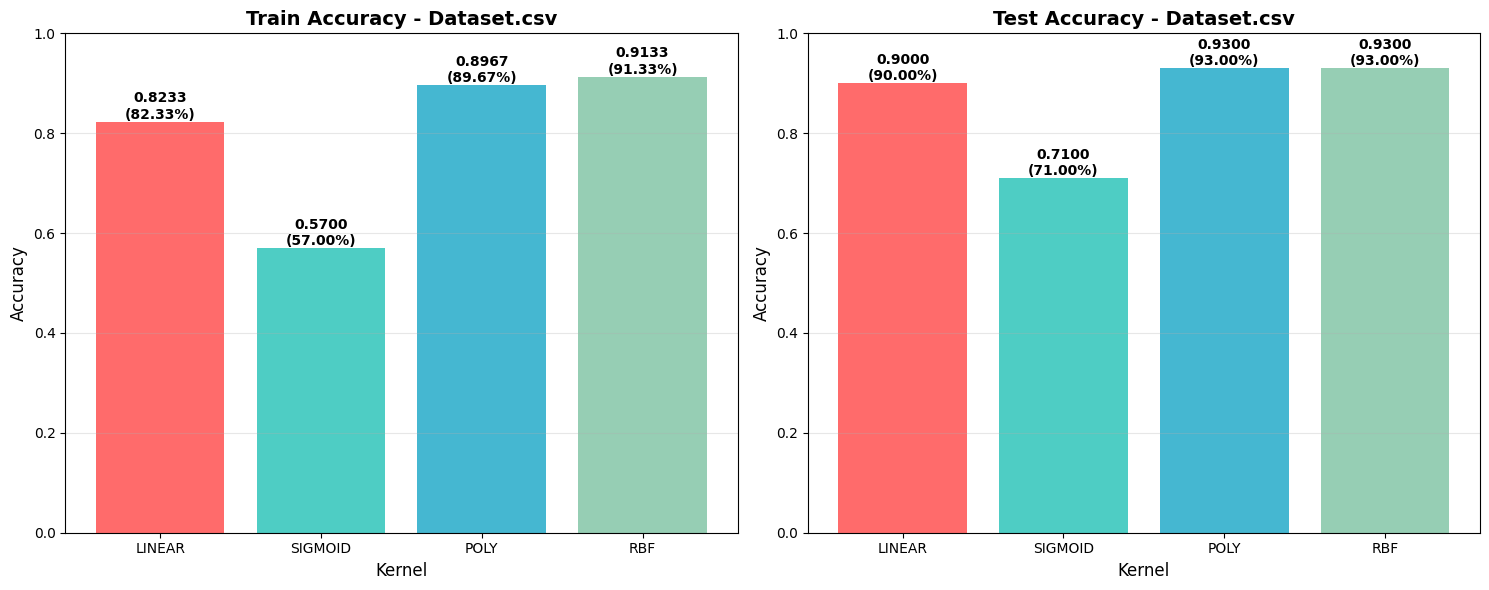

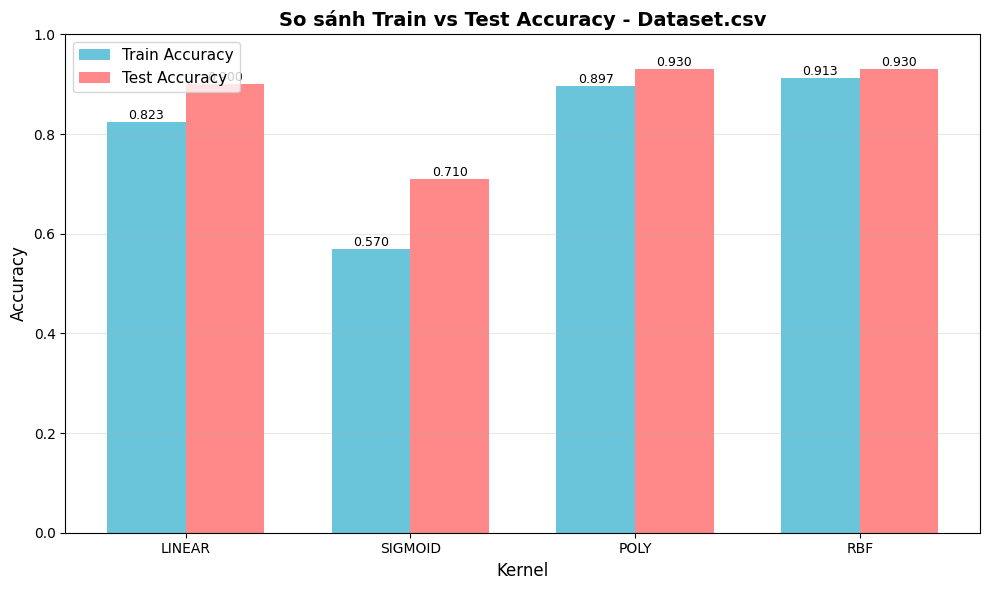

In [40]:
# Tổng hợp và so sánh kết quả các kernel
print("\n" + "="*80)
print("TỔNG HỢP KẾT QUẢ SO SÁNH CÁC KERNEL - DATASET.CSV")
print("="*80)

# Tạo DataFrame để hiển thị kết quả
comparison_data_dataset = []
for kernel_name, result in results_dataset.items():
    comparison_data_dataset.append({
        'Kernel': kernel_name.upper(),
        'Train Accuracy': f"{result['train_accuracy']:.4f}",
        'Train Acc (%)': f"{result['train_accuracy']*100:.2f}%",
        'Test Accuracy': f"{result['test_accuracy']:.4f}",
        'Test Acc (%)': f"{result['test_accuracy']*100:.2f}%"
    })

df_comparison_dataset = pd.DataFrame(comparison_data_dataset)
print("\n", df_comparison_dataset.to_string(index=False))

# Tìm kernel tốt nhất dựa trên test accuracy
best_kernel_dataset = max(results_dataset.items(), key=lambda x: x[1]['test_accuracy'])
print(f"\n{'='*80}")
print(f"KERNEL TỐT NHẤT (dựa trên Test Accuracy): {best_kernel_dataset[0].upper()}")
print(f"Train Accuracy: {best_kernel_dataset[1]['train_accuracy']:.4f} ({best_kernel_dataset[1]['train_accuracy']*100:.2f}%)")
print(f"Test Accuracy: {best_kernel_dataset[1]['test_accuracy']:.4f} ({best_kernel_dataset[1]['test_accuracy']*100:.2f}%)")
print(f"{'='*80}")

# Vẽ biểu đồ so sánh accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

kernel_names_ds = [k.upper() for k in results_dataset.keys()]
train_accuracies_ds = [results_dataset[k]['train_accuracy'] for k in results_dataset.keys()]
test_accuracies_ds = [results_dataset[k]['test_accuracy'] for k in results_dataset.keys()]

# Biểu đồ Train Accuracy
bars1 = ax1.bar(kernel_names_ds, train_accuracies_ds, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('Kernel', fontsize=12)
ax1.set_title('Train Accuracy - Dataset.csv', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars1, train_accuracies_ds):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}\n({acc*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Biểu đồ Test Accuracy
bars2 = ax2.bar(kernel_names_ds, test_accuracies_ds, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xlabel('Kernel', fontsize=12)
ax2.set_title('Test Accuracy - Dataset.csv', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1.0])
ax2.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars2, test_accuracies_ds):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}\n({acc*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Vẽ biểu đồ so sánh Train vs Test Accuracy
plt.figure(figsize=(10, 6))
x_pos = np.arange(len(kernel_names_ds))
width = 0.35

bars1 = plt.bar(x_pos - width/2, train_accuracies_ds, width, label='Train Accuracy', 
                color='#45B7D1', alpha=0.8)
bars2 = plt.bar(x_pos + width/2, test_accuracies_ds, width, label='Test Accuracy', 
                color='#FF6B6B', alpha=0.8)

plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Kernel', fontsize=12)
plt.title('So sánh Train vs Test Accuracy - Dataset.csv', fontsize=14, fontweight='bold')
plt.xticks(x_pos, kernel_names_ds)
plt.ylim([0, 1.0])
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

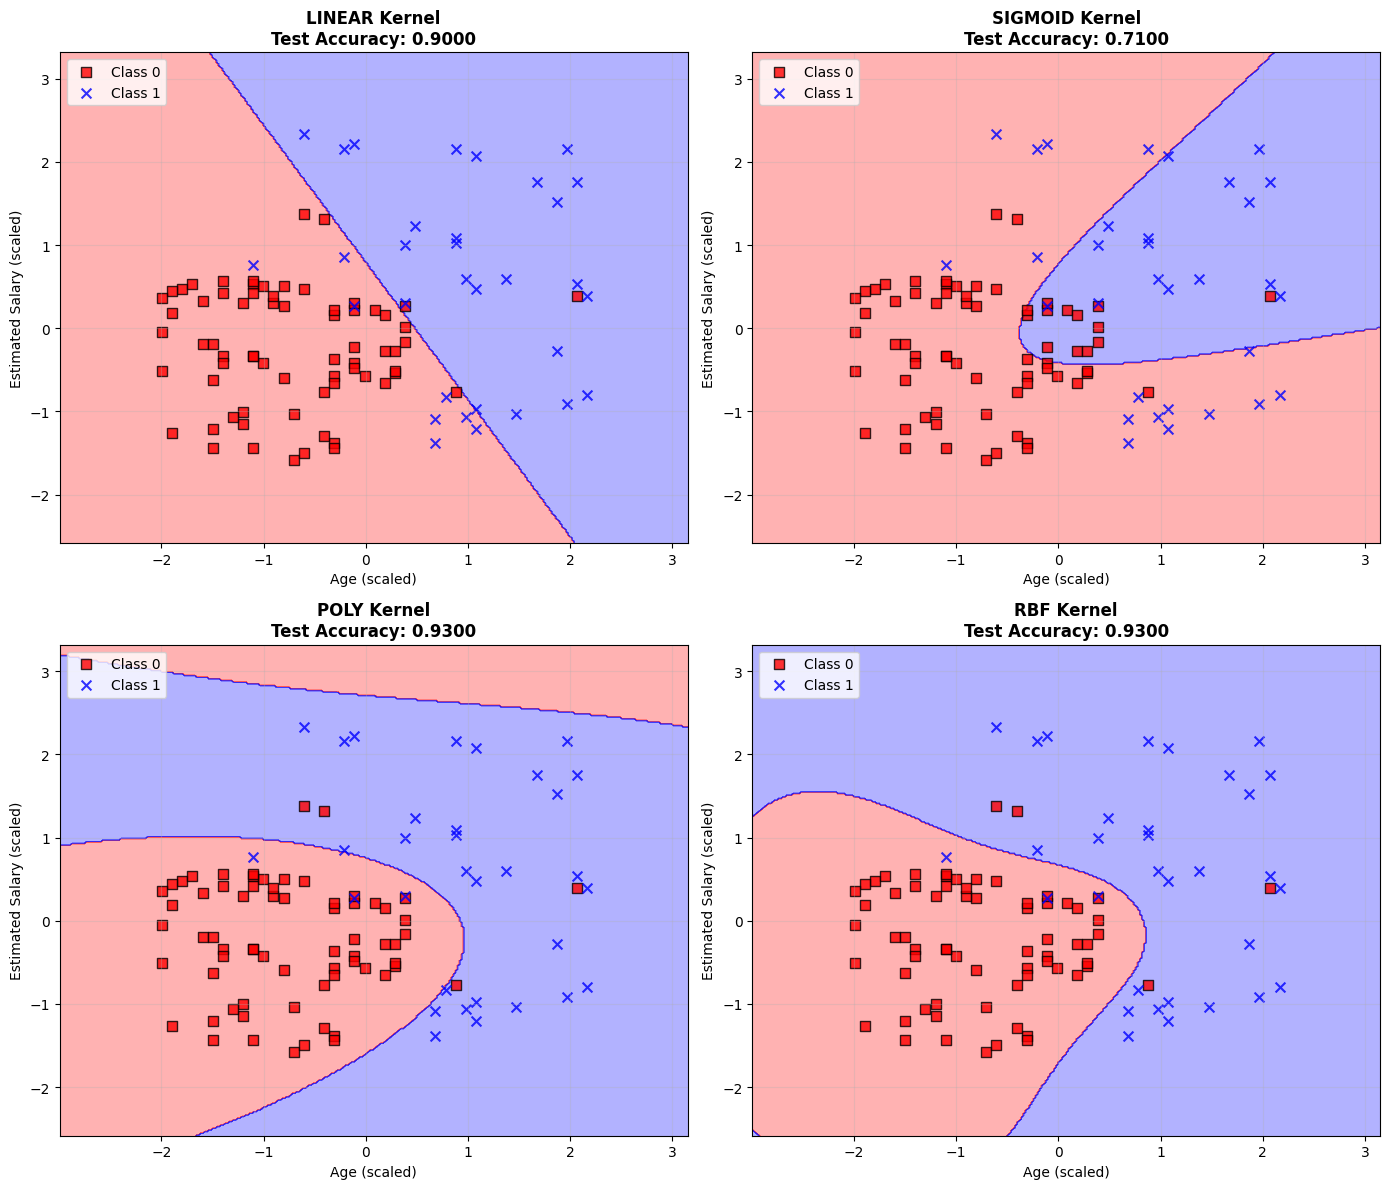


Đã vẽ Decision Boundary cho tất cả các kernel trên tập Test!


In [41]:
# Visualize Decision Boundary cho từng kernel
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X, y, classifier, title, kernel_name):
    """
    Vẽ decision boundary cho classifier
    """
    h = 0.02  # step size in the mesh
    
    # Setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    # Plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h),
                           np.arange(x2_min, x2_max, h))
    
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    # Plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                   alpha=0.8, c=colors[idx],
                   marker=markers[idx], label=f'Class {cl}',
                   edgecolor='black', s=50)
    
    plt.xlabel('Age (scaled)')
    plt.ylabel('Estimated Salary (scaled)')
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)

# Vẽ decision boundary cho tất cả các kernel
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (kernel_name, result) in enumerate(results_dataset.items()):
    plt.subplot(2, 2, idx + 1)
    plot_decision_boundary(XTest, yTest, result['model'], 
                          f'{kernel_name.upper()} Kernel\nTest Accuracy: {result["test_accuracy"]:.4f}',
                          kernel_name)

plt.tight_layout()
plt.show()

print("\nĐã vẽ Decision Boundary cho tất cả các kernel trên tập Test!")

## Bài tập thực hành 3

In [42]:
# Import thư viện cần thiết
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

plt.style.use('ggplot')

# Tải dữ liệu Breast Cancer từ sklearn
data_cancer = load_breast_cancer()

# Hiển thị thông tin về dataset
print("="*80)
print("THÔNG TIN VỀ BREAST CANCER DATASET")
print("="*80)
print(f"\nTên các features ({len(data_cancer.feature_names)} features):")
print(data_cancer.feature_names)
print(f"\nTên các class ({len(data_cancer.target_names)} classes):")
print(data_cancer.target_names)
print(f"\nMô tả dataset:")
print(f"  - Số lượng mẫu: {data_cancer.data.shape[0]}")
print(f"  - Số lượng features: {data_cancer.data.shape[1]}")
print(f"\nPhân bố class:")
unique, counts = np.unique(data_cancer.target, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  - {data_cancer.target_names[u]} ({u}): {c} mẫu ({c/len(data_cancer.target)*100:.2f}%)")

# Tạo DataFrame để dễ xem
df_cancer = pd.DataFrame(data_cancer.data, columns=data_cancer.feature_names)
df_cancer['target'] = data_cancer.target
df_cancer['target_name'] = df_cancer['target'].apply(lambda x: data_cancer.target_names[x])

print(f"\n5 dòng đầu tiên của dataset:")
print(df_cancer.head())
print(f"\nThống kê mô tả:")
print(df_cancer.describe())

THÔNG TIN VỀ BREAST CANCER DATASET

Tên các features (30 features):
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Tên các class (2 classes):
['malignant' 'benign']

Mô tả dataset:
  - Số lượng mẫu: 569
  - Số lượng features: 30

Phân bố class:
  - malignant (0): 212 mẫu (37.26%)
  - benign (1): 357 mẫu (62.74%)

5 dòng đầu tiên của dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.1184

In [43]:
# Chuẩn bị dữ liệu
X_cancer = data_cancer.data
y_cancer = data_cancer.target

# Chuyển đổi labels từ 0,1 sang -1,1 (theo yêu cầu)
# 0 (malignant - ác tính) -> -1
# 1 (benign - lành tính) -> 1
y_cancer_converted = np.where(y_cancer == 0, -1, 1)

print("Chuyển đổi labels:")
print(f"  Original: 0 (malignant), 1 (benign)")
print(f"  Converted: -1 (malignant), 1 (benign)")
print(f"\nPhân bố sau khi chuyển đổi:")
unique_conv, counts_conv = np.unique(y_cancer_converted, return_counts=True)
for u, c in zip(unique_conv, counts_conv):
    label_name = "malignant" if u == -1 else "benign"
    print(f"  - {label_name} ({u}): {c} mẫu")

# Chia dữ liệu thành train và test (75% train, 25% test)
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer_converted, test_size=0.25, random_state=42, stratify=y_cancer_converted
)

print(f"\nKích thước dữ liệu:")
print(f"  - X_train: {X_train_cancer.shape}")
print(f"  - X_test: {X_test_cancer.shape}")
print(f"  - y_train: {y_train_cancer.shape}")
print(f"  - y_test: {y_test_cancer.shape}")

# Chuẩn hóa dữ liệu (Feature Scaling)
from sklearn.preprocessing import StandardScaler
sc_cancer = StandardScaler()
X_train_cancer_scaled = sc_cancer.fit_transform(X_train_cancer)
X_test_cancer_scaled = sc_cancer.transform(X_test_cancer)

print(f"\nDữ liệu đã được chuẩn hóa (StandardScaler)")
print(f"Mean của X_train sau chuẩn hóa (5 features đầu): {X_train_cancer_scaled.mean(axis=0)[:5]}")
print(f"Std của X_train sau chuẩn hóa (5 features đầu): {X_train_cancer_scaled.std(axis=0)[:5]}")

Chuyển đổi labels:
  Original: 0 (malignant), 1 (benign)
  Converted: -1 (malignant), 1 (benign)

Phân bố sau khi chuyển đổi:
  - malignant (-1): 212 mẫu
  - benign (1): 357 mẫu

Kích thước dữ liệu:
  - X_train: (426, 30)
  - X_test: (143, 30)
  - y_train: (426,)
  - y_test: (143,)

Dữ liệu đã được chuẩn hóa (StandardScaler)
Mean của X_train sau chuẩn hóa (5 features đầu): [-4.68430719e-15  3.92226679e-16 -2.25693225e-15  1.54962115e-15
 -4.46955983e-16]
Std của X_train sau chuẩn hóa (5 features đầu): [1. 1. 1. 1. 1.]


PCA - Phương sai được giải thích bởi 2 components:
  - PC1: 0.4390 (43.90%)
  - PC2: 0.1952 (19.52%)
  - Tổng: 0.6341 (63.41%)


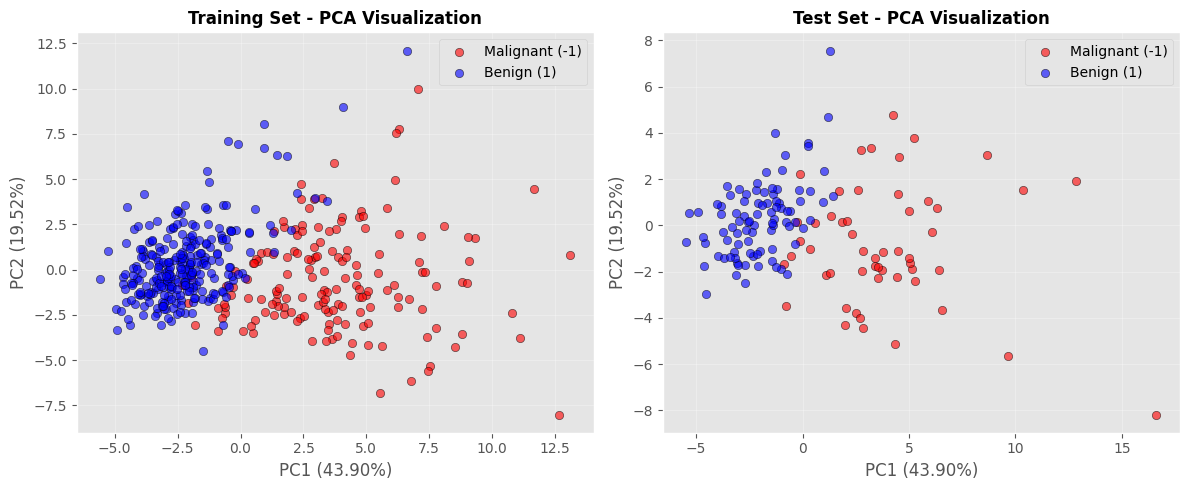

In [44]:
# Visualize dữ liệu - sử dụng PCA để giảm xuống 2D cho visualization
from sklearn.decomposition import PCA

# Áp dụng PCA để giảm từ 30 features xuống 2 features cho visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_cancer_scaled)
X_test_pca = pca.transform(X_test_cancer_scaled)

print(f"PCA - Phương sai được giải thích bởi 2 components:")
print(f"  - PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  - PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  - Tổng: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))

# Subplot 1: Training set
plt.subplot(1, 2, 1)
plt.scatter(X_train_pca[y_train_cancer==-1, 0], X_train_pca[y_train_cancer==-1, 1], 
           c='red', label='Malignant (-1)', alpha=0.6, edgecolors='k')
plt.scatter(X_train_pca[y_train_cancer==1, 0], X_train_pca[y_train_cancer==1, 1], 
           c='blue', label='Benign (1)', alpha=0.6, edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('Training Set - PCA Visualization', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: Test set
plt.subplot(1, 2, 2)
plt.scatter(X_test_pca[y_test_cancer==-1, 0], X_test_pca[y_test_cancer==-1, 1], 
           c='red', label='Malignant (-1)', alpha=0.6, edgecolors='k')
plt.scatter(X_test_pca[y_test_cancer==1, 0], X_test_pca[y_test_cancer==1, 1], 
           c='blue', label='Benign (1)', alpha=0.6, edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('Test Set - PCA Visualization', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

TRAINING VÀ ĐÁNH GIÁ KERNEL SVM CHO BREAST CANCER DATASET

Kernel: LINEAR
Đang training model...
Training hoàn tất! Số support vectors: 34

KẾT QUẢ:
  Accuracy trên tập Training: 0.9906 (99.06%)
  Accuracy trên tập Test: 0.9860 (98.60%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[52  1]
 [ 1 89]]


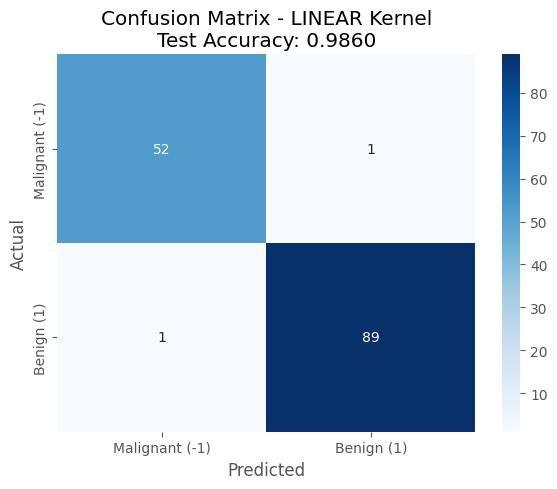


Phân tích chi tiết:
  - True Negatives (TN): 52 (Dự đoán đúng Malignant)
  - False Positives (FP): 1 (Dự đoán sai thành Benign)
  - False Negatives (FN): 1 (Dự đoán sai thành Malignant)
  - True Positives (TP): 89 (Dự đoán đúng Benign)

Các metrics quan trọng (cho class Benign):
  - Precision: 0.9889 (Tỷ lệ dự đoán Benign đúng)
  - Recall: 0.9889 (Tỷ lệ phát hiện được Benign)
  - F1-Score: 0.9889 (Trung bình điều hòa của Precision và Recall)

Kernel: SIGMOID
Đang training model...
Training hoàn tất! Số support vectors: 72

KẾT QUẢ:
  Accuracy trên tập Training: 0.9131 (91.31%)
  Accuracy trên tập Test: 0.9371 (93.71%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[46  7]
 [ 2 88]]


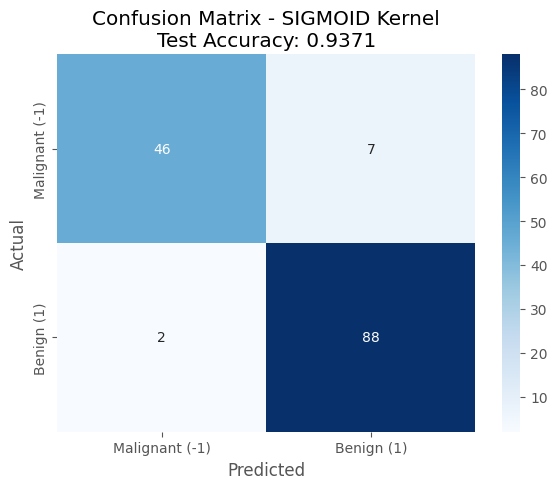


Phân tích chi tiết:
  - True Negatives (TN): 46 (Dự đoán đúng Malignant)
  - False Positives (FP): 7 (Dự đoán sai thành Benign)
  - False Negatives (FN): 2 (Dự đoán sai thành Malignant)
  - True Positives (TP): 88 (Dự đoán đúng Benign)

Các metrics quan trọng (cho class Benign):
  - Precision: 0.9263 (Tỷ lệ dự đoán Benign đúng)
  - Recall: 0.9778 (Tỷ lệ phát hiện được Benign)
  - F1-Score: 0.9514 (Trung bình điều hòa của Precision và Recall)

Kernel: POLY
Đang training model...
Training hoàn tất! Số support vectors: 56

KẾT QUẢ:
  Accuracy trên tập Training: 0.9883 (98.83%)
  Accuracy trên tập Test: 0.9930 (99.30%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[52  1]
 [ 0 90]]


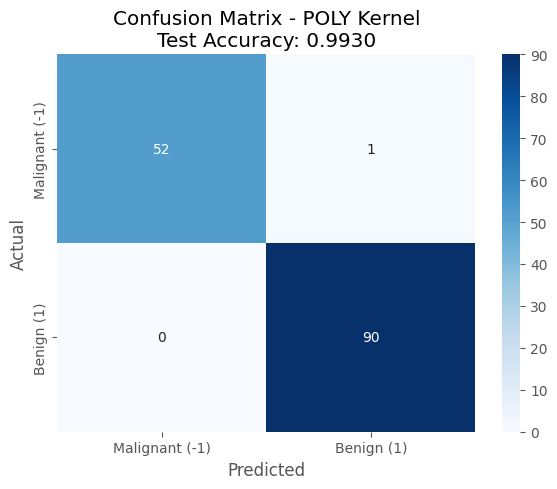


Phân tích chi tiết:
  - True Negatives (TN): 52 (Dự đoán đúng Malignant)
  - False Positives (FP): 1 (Dự đoán sai thành Benign)
  - False Negatives (FN): 0 (Dự đoán sai thành Malignant)
  - True Positives (TP): 90 (Dự đoán đúng Benign)

Các metrics quan trọng (cho class Benign):
  - Precision: 0.9890 (Tỷ lệ dự đoán Benign đúng)
  - Recall: 1.0000 (Tỷ lệ phát hiện được Benign)
  - F1-Score: 0.9945 (Trung bình điều hòa của Precision và Recall)

Kernel: RBF
Đang training model...
Training hoàn tất! Số support vectors: 96

KẾT QUẢ:
  Accuracy trên tập Training: 0.9789 (97.89%)
  Accuracy trên tập Test: 0.9790 (97.90%)

Ma trận nhầm lẫn (Confusion Matrix) trên tập Test:
[[52  1]
 [ 2 88]]


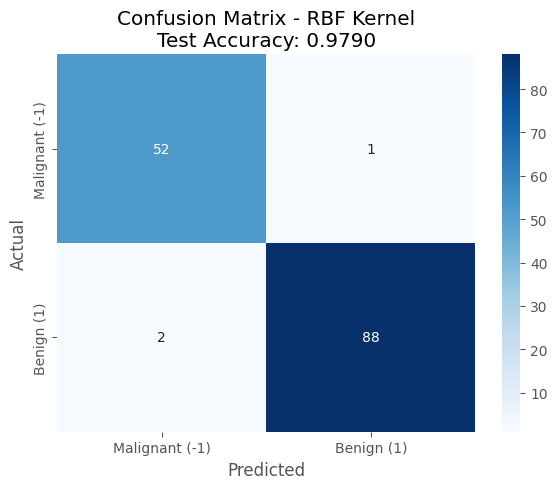


Phân tích chi tiết:
  - True Negatives (TN): 52 (Dự đoán đúng Malignant)
  - False Positives (FP): 1 (Dự đoán sai thành Benign)
  - False Negatives (FN): 2 (Dự đoán sai thành Malignant)
  - True Positives (TP): 88 (Dự đoán đúng Benign)

Các metrics quan trọng (cho class Benign):
  - Precision: 0.9888 (Tỷ lệ dự đoán Benign đúng)
  - Recall: 0.9778 (Tỷ lệ phát hiện được Benign)
  - F1-Score: 0.9832 (Trung bình điều hòa của Precision và Recall)

HOÀN THÀNH TRAINING VÀ ĐÁNH GIÁ TẤT CẢ CÁC KERNEL


In [45]:
# Danh sách các kernel để test
kernels_cancer = ['linear', 'sigmoid', 'poly', 'rbf']

# Dictionary để lưu kết quả
results_cancer = {}

print("="*80)
print("TRAINING VÀ ĐÁNH GIÁ KERNEL SVM CHO BREAST CANCER DATASET")
print("="*80)

# Training và đánh giá cho mỗi kernel
for kernel_name in kernels_cancer:
    print(f"\n{'='*80}")
    print(f"Kernel: {kernel_name.upper()}")
    print(f"{'='*80}")
    
    # Khởi tạo model với kernel tương ứng
    if kernel_name == 'poly':
        clf = SVC(kernel=kernel_name, gamma='scale', coef0=1, degree=3, random_state=42)
    else:
        clf = SVC(kernel=kernel_name, gamma='scale', coef0=1, random_state=42)
    
    # Training
    print("Đang training model...")
    clf.fit(X_train_cancer_scaled, y_train_cancer)
    print(f"Training hoàn tất! Số support vectors: {len(clf.support_vectors_)}")
    
    # Dự đoán trên tập training
    y_train_pred_cancer = clf.predict(X_train_cancer_scaled)
    train_accuracy = accuracy_score(y_train_cancer, y_train_pred_cancer)
    
    # Dự đoán trên tập test
    y_test_pred_cancer = clf.predict(X_test_cancer_scaled)
    test_accuracy = accuracy_score(y_test_cancer, y_test_pred_cancer)
    
    # Tính confusion matrix cho tập test
    cm = confusion_matrix(y_test_cancer, y_test_pred_cancer)
    
    # Lưu kết quả
    results_cancer[kernel_name] = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'confusion_matrix': cm,
        'model': clf,
        'y_test_pred': y_test_pred_cancer
    }
    
    # In kết quả
    print(f"\nKẾT QUẢ:")
    print(f"  Accuracy trên tập Training: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"  Accuracy trên tập Test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"\nMa trận nhầm lẫn (Confusion Matrix) trên tập Test:")
    print(cm)
    
    # Visualize confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Malignant (-1)', 'Benign (1)'],
                yticklabels=['Malignant (-1)', 'Benign (1)'])
    plt.title(f'Confusion Matrix - {kernel_name.upper()} Kernel\nTest Accuracy: {test_accuracy:.4f}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    print(f"\nPhân tích chi tiết:")
    print(f"  - True Negatives (TN): {cm[0,0]} (Dự đoán đúng Malignant)")
    print(f"  - False Positives (FP): {cm[0,1]} (Dự đoán sai thành Benign)")
    print(f"  - False Negatives (FN): {cm[1,0]} (Dự đoán sai thành Malignant)")
    print(f"  - True Positives (TP): {cm[1,1]} (Dự đoán đúng Benign)")
    
    # Tính thêm các metrics quan trọng cho bài toán y tế
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    # Chuyển đổi -1,1 về 0,1 để tính precision, recall, f1
    y_test_binary = np.where(y_test_cancer == -1, 0, 1)
    y_pred_binary = np.where(y_test_pred_cancer == -1, 0, 1)
    
    precision = precision_score(y_test_binary, y_pred_binary)
    recall = recall_score(y_test_binary, y_pred_binary)
    f1 = f1_score(y_test_binary, y_pred_binary)
    
    print(f"\nCác metrics quan trọng (cho class Benign):")
    print(f"  - Precision: {precision:.4f} (Tỷ lệ dự đoán Benign đúng)")
    print(f"  - Recall: {recall:.4f} (Tỷ lệ phát hiện được Benign)")
    print(f"  - F1-Score: {f1:.4f} (Trung bình điều hòa của Precision và Recall)")
    
    results_cancer[kernel_name]['precision'] = precision
    results_cancer[kernel_name]['recall'] = recall
    results_cancer[kernel_name]['f1_score'] = f1

print(f"\n{'='*80}")
print("HOÀN THÀNH TRAINING VÀ ĐÁNH GIÁ TẤT CẢ CÁC KERNEL")
print(f"{'='*80}")

In [46]:
# Tổng hợp và so sánh kết quả các kernel
print("\n" + "="*80)
print("TỔNG HỢP KẾT QUẢ SO SÁNH CÁC KERNEL - BREAST CANCER DATASET")
print("="*80)

# Tạo DataFrame để hiển thị kết quả đầy đủ
comparison_data_cancer = []
for kernel_name, result in results_cancer.items():
    comparison_data_cancer.append({
        'Kernel': kernel_name.upper(),
        'Train Acc': f"{result['train_accuracy']:.4f}",
        'Test Acc': f"{result['test_accuracy']:.4f}",
        'Precision': f"{result['precision']:.4f}",
        'Recall': f"{result['recall']:.4f}",
        'F1-Score': f"{result['f1_score']:.4f}"
    })

df_comparison_cancer = pd.DataFrame(comparison_data_cancer)
print("\n", df_comparison_cancer.to_string(index=False))

# Tìm kernel tốt nhất dựa trên test accuracy
best_kernel_cancer = max(results_cancer.items(), key=lambda x: x[1]['test_accuracy'])
print(f"\n{'='*80}")
print(f"KERNEL TỐT NHẤT (dựa trên Test Accuracy): {best_kernel_cancer[0].upper()}")
print(f"  Train Accuracy: {best_kernel_cancer[1]['train_accuracy']:.4f} ({best_kernel_cancer[1]['train_accuracy']*100:.2f}%)")
print(f"  Test Accuracy: {best_kernel_cancer[1]['test_accuracy']:.4f} ({best_kernel_cancer[1]['test_accuracy']*100:.2f}%)")
print(f"  Precision: {best_kernel_cancer[1]['precision']:.4f}")
print(f"  Recall: {best_kernel_cancer[1]['recall']:.4f}")
print(f"  F1-Score: {best_kernel_cancer[1]['f1_score']:.4f}")
print(f"{'='*80}")


TỔNG HỢP KẾT QUẢ SO SÁNH CÁC KERNEL - BREAST CANCER DATASET

  Kernel Train Acc Test Acc Precision Recall F1-Score
 LINEAR    0.9906   0.9860    0.9889 0.9889   0.9889
SIGMOID    0.9131   0.9371    0.9263 0.9778   0.9514
   POLY    0.9883   0.9930    0.9890 1.0000   0.9945
    RBF    0.9789   0.9790    0.9888 0.9778   0.9832

KERNEL TỐT NHẤT (dựa trên Test Accuracy): POLY
  Train Accuracy: 0.9883 (98.83%)
  Test Accuracy: 0.9930 (99.30%)
  Precision: 0.9890
  Recall: 1.0000
  F1-Score: 0.9945


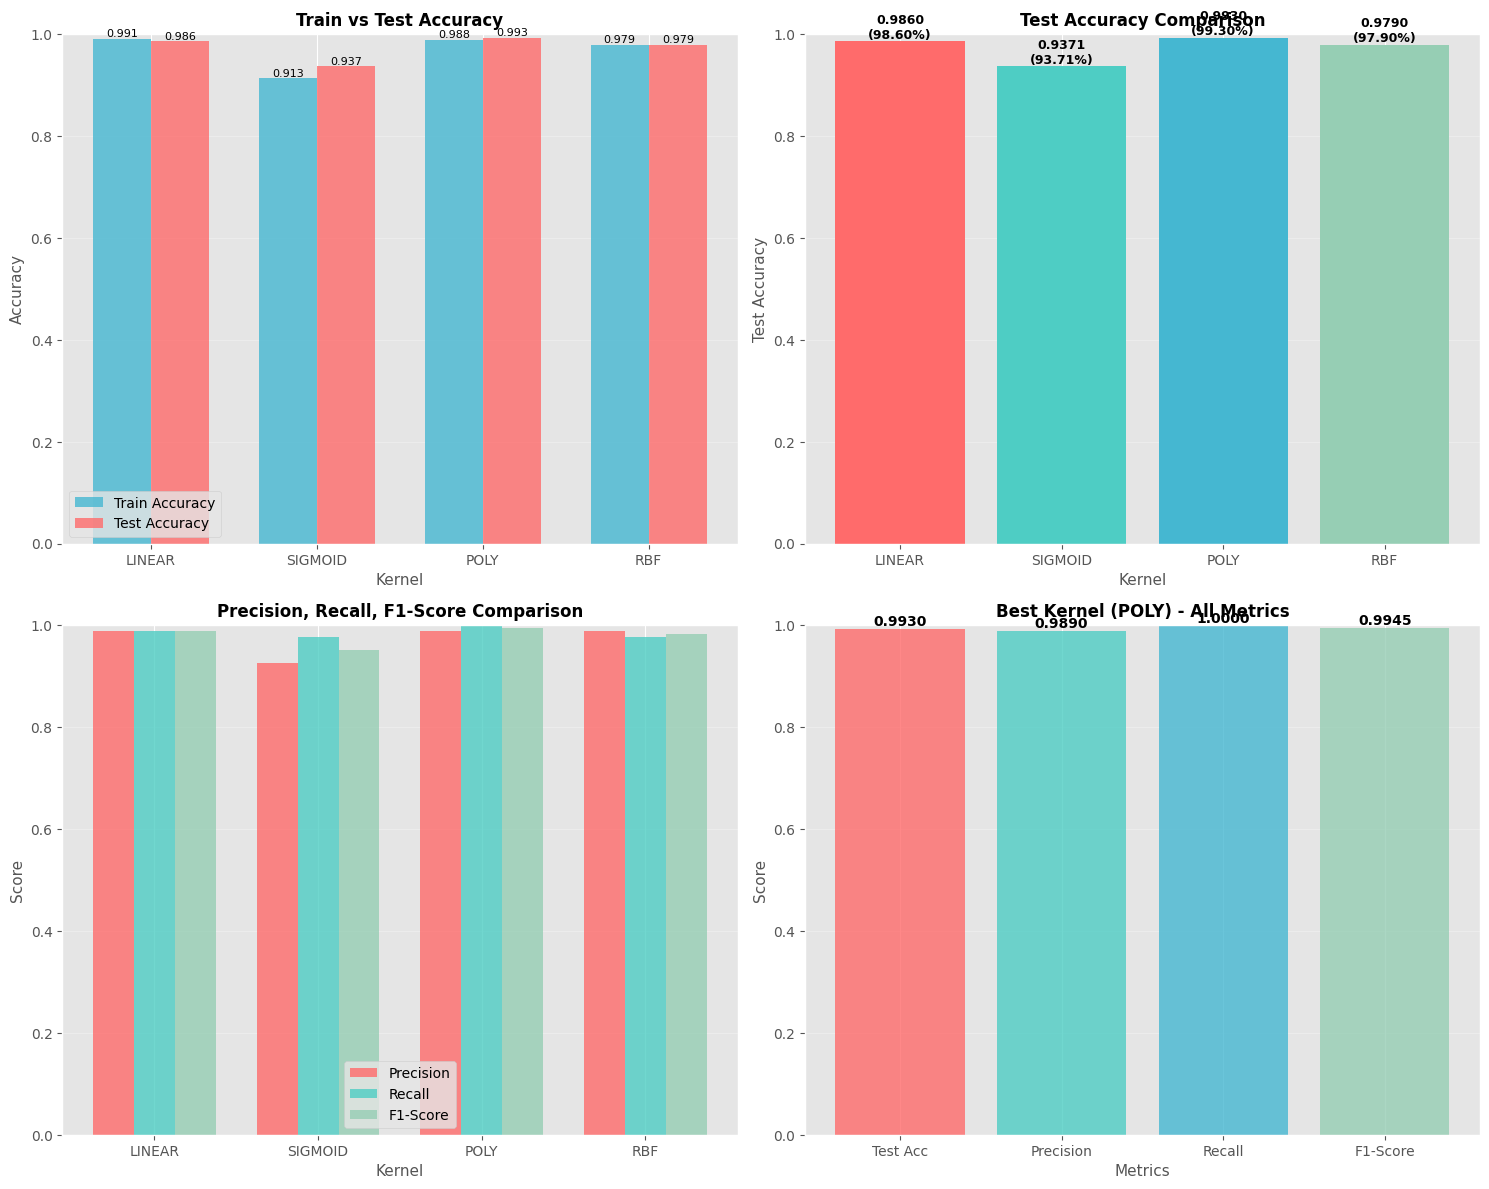

In [47]:
# Vẽ biểu đồ so sánh các metrics
kernel_names_cancer = [k.upper() for k in results_cancer.keys()]
train_accs_cancer = [results_cancer[k]['train_accuracy'] for k in results_cancer.keys()]
test_accs_cancer = [results_cancer[k]['test_accuracy'] for k in results_cancer.keys()]
precisions_cancer = [results_cancer[k]['precision'] for k in results_cancer.keys()]
recalls_cancer = [results_cancer[k]['recall'] for k in results_cancer.keys()]
f1_scores_cancer = [results_cancer[k]['f1_score'] for k in results_cancer.keys()]

# Biểu đồ 1: Train vs Test Accuracy
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Subplot 1: Train vs Test Accuracy
ax1 = axes[0, 0]
x_pos = np.arange(len(kernel_names_cancer))
width = 0.35
bars1 = ax1.bar(x_pos - width/2, train_accs_cancer, width, label='Train Accuracy', 
                color='#45B7D1', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, test_accs_cancer, width, label='Test Accuracy', 
                color='#FF6B6B', alpha=0.8)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_xlabel('Kernel', fontsize=11)
ax1.set_title('Train vs Test Accuracy', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(kernel_names_cancer)
ax1.set_ylim([0, 1.0])
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Subplot 2: Test Accuracy comparison
ax2 = axes[0, 1]
bars = ax2.bar(kernel_names_cancer, test_accs_cancer, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax2.set_ylabel('Test Accuracy', fontsize=11)
ax2.set_xlabel('Kernel', fontsize=11)
ax2.set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1.0])
ax2.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, test_accs_cancer):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}\n({acc*100:.2f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Subplot 3: Precision, Recall, F1-Score
ax3 = axes[1, 0]
x_pos = np.arange(len(kernel_names_cancer))
width = 0.25
bars1 = ax3.bar(x_pos - width, precisions_cancer, width, label='Precision', color='#FF6B6B', alpha=0.8)
bars2 = ax3.bar(x_pos, recalls_cancer, width, label='Recall', color='#4ECDC4', alpha=0.8)
bars3 = ax3.bar(x_pos + width, f1_scores_cancer, width, label='F1-Score', color='#96CEB4', alpha=0.8)
ax3.set_ylabel('Score', fontsize=11)
ax3.set_xlabel('Kernel', fontsize=11)
ax3.set_title('Precision, Recall, F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(kernel_names_cancer)
ax3.set_ylim([0, 1.0])
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# Subplot 4: Overall Performance Radar Chart (alternative view)
ax4 = axes[1, 1]
metrics = ['Test Acc', 'Precision', 'Recall', 'F1-Score']
best_idx = np.argmax(test_accs_cancer)
best_metrics = [
    test_accs_cancer[best_idx],
    precisions_cancer[best_idx],
    recalls_cancer[best_idx],
    f1_scores_cancer[best_idx]
]
x_metrics = np.arange(len(metrics))
bars = ax4.bar(x_metrics, best_metrics, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8)
ax4.set_ylabel('Score', fontsize=11)
ax4.set_xlabel('Metrics', fontsize=11)
ax4.set_title(f'Best Kernel ({kernel_names_cancer[best_idx]}) - All Metrics', fontsize=12, fontweight='bold')
ax4.set_xticks(x_metrics)
ax4.set_xticklabels(metrics)
ax4.set_ylim([0, 1.0])
ax4.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, best_metrics):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Visualize Decision Boundary trên không gian PCA (2D)
from matplotlib.colors import ListedColormap

def plot_decision_boundary_pca(X_pca, y, classifier, title, kernel_name):
    """
    Vẽ decision boundary cho classifier trên không gian PCA 2D
    """
    h = 0.02  # step size in the mesh
    
    # Setup marker generator and color map
    markers = ('o', 's')
    colors = ('red', 'blue')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    # Plot the decision surface
    x1_min, x1_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    x2_min, x2_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h),
                           np.arange(x2_min, x2_max, h))
    
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    # Plot class samples
    for idx, cl in enumerate(np.unique(y)):
        label_name = 'Malignant (-1)' if cl == -1 else 'Benign (1)'
        plt.scatter(x=X_pca[y == cl, 0], y=X_pca[y == cl, 1],
                   alpha=0.8, c=colors[idx],
                   marker=markers[idx], label=label_name,
                   edgecolor='black', s=50)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
    plt.title(title, fontsize=11, fontweight='bold')
    plt.legend(loc='best', fontsize=9)
    plt.grid(alpha=0.3)

# Train models trên dữ liệu PCA để visualize decision boundary
print("Training models trên dữ liệu PCA để visualize decision boundary...")
results_cancer_pca = {}

for kernel_name in kernels_cancer:
    if kernel_name == 'poly':
        clf_pca = SVC(kernel=kernel_name, gamma='scale', coef0=1, degree=3, random_state=42)
    else:
        clf_pca = SVC(kernel=kernel_name, gamma='scale', coef0=1, random_state=42)
    
    clf_pca.fit(X_train_pca, y_train_cancer)
    y_test_pred_pca = clf_pca.predict(X_test_pca)
    test_acc_pca = accuracy_score(y_test_cancer, y_test_pred_pca)
    
    results_cancer_pca[kernel_name] = {
        'model': clf_pca,
        'test_accuracy': test_acc_pca
    }

# Vẽ decision boundary cho tất cả các kernel
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (kernel_name, result) in enumerate(results_cancer_pca.items()):
    plt.subplot(2, 2, idx + 1)
    plot_decision_boundary_pca(X_test_pca, y_test_cancer, result['model'], 
                              f'{kernel_name.upper()} Kernel\nTest Accuracy (PCA): {result["test_accuracy"]:.4f}',
                              kernel_name)

plt.tight_layout()
plt.show()

print("\nĐã vẽ Decision Boundary cho tất cả các kernel trên không gian PCA!")
print("Lưu ý: Decision boundary được vẽ trên không gian PCA 2D, không phải không gian gốc 30D")